# EDA - Passos Mágicos | PEDE 2022-2024

Notebook de análise exploratória da base `BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx`, reorganizado a partir de uma primeira versão da EDA e da base de conhecimento consolidada em:

- `01_Analise_Direcionamento_PEDE.md` — cruzamento do dicionário de dados, do PDF de indicadores e do Excel, com direcionamento pergunta a pergunta.
- `02_Base_Conhecimento_PEDE.md` — glossário de indicadores, fórmulas oficiais, tabelas de referência e registro de problemas de qualidade de dado.

**Perguntas de negócio cobertas neste notebook**
1. **IAN** — perfil de defasagem dos alunos e evolução anual.
2. **IDA** — evolução do desempenho acadêmico por ano e fase.
3. **IEG** — relação entre engajamento, desempenho acadêmico e ponto de virada.
4. **IAA** — coerência entre autoavaliação, desempenho real e engajamento.
5. **IPS** — sinais psicossociais que antecedem quedas em desempenho ou engajamento.
6. **IPP** — convergência ou contradição entre avaliação psicopedagógica e defasagem (IAN).
7. **IPV** — comportamentos mais associados ao ponto de virada.
8. **INDE** — combinações multidimensionais que elevam a nota global.
9. **ML (discussão)** — caminhos possíveis para definir o alvo de um modelo de risco (sem treinar modelo nesta etapa).
10. **Efetividade do programa** — transição de Pedra (Quartzo/Ágata/Ametista/Topázio) ao longo dos ciclos.


## Contexto de negócio em linguagem simples

A Passos Mágicos não olha apenas para nota escolar. A organização acompanha o desenvolvimento do aluno por um índice composto, o **INDE**, que junta dimensões acadêmicas, psicossociais e psicopedagógicas.

Em termos práticos, o problema de negócio é responder:

- **Quem está defasado em relação à fase esperada para a idade?**
- **Quem tem bom desempenho acadêmico, mas baixo engajamento?**
- **Quem se percebe bem, mas tem desempenho ou engajamento baixo?**
- **Quais sinais psicossociais ou psicopedagógicos podem antecipar queda futura?**
- **Quais combinações de indicadores elevam ou reduzem o INDE?**
- **O programa está, de fato, fazendo os alunos evoluírem de faixa (Pedra) ao longo do tempo?**

### Como os indicadores se organizam

| Dimensão | Indicadores | Leitura de negócio |
|---|---|---|
| Acadêmica | `IAN`, `IDA`, `IEG` | Nível adequado, desempenho e engajamento nas atividades |
| Psicossocial | `IAA`, `IPS` | Autopercepção do aluno e avaliação psicossocial |
| Psicopedagógica / Conselho | `IPP`, `IPV` | Aspectos pedagógicos, emocionais e ponto de virada |
| Síntese | `INDE` | Nota global ponderada do desenvolvimento educacional |

Importante: o dicionário de dados e o PDF de indicadores foram usados como **contexto de negócio** para explicar os campos e validar as fórmulas. A análise estatística abaixo é feita a partir da base Excel efetivamente carregada no notebook — quando a planilha diverge do que o dicionário descreve, isso é sinalizado explicitamente.


## 1. Setup

Bibliotecas padrão de análise de dados (pandas, numpy, matplotlib, seaborn) e, quando disponível, `scikit-learn` para os modelos exploratórios de importância de variável (usados nas seções de IPV e INDE — não são o modelo de risco da pergunta 9, que é tratado à parte na Seção 14).


In [1]:
import re
import warnings
import unicodedata
import datetime
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

try:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.impute import SimpleImputer
    from sklearn.inspection import permutation_importance
    from sklearn.metrics import mean_absolute_error, r2_score
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    SKLEARN_OK = True
except Exception as exc:
    SKLEARN_OK = False
    SKLEARN_ERROR = exc

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("Ambiente pronto.")
print("sklearn disponível:", SKLEARN_OK)


Ambiente pronto.
sklearn disponível: True


## 2. Leitura do Excel

Cada aba representa uma fotografia anual da PEDE (`PEDE2022`, `PEDE2023`, `PEDE2024`). Como as colunas mudam entre os anos, lemos tudo cru primeiro e padronizamos na seção seguinte.


In [2]:
DATA_DIR = Path.cwd()
EXCEL_FILE = DATA_DIR / "BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx"

if not EXCEL_FILE.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {EXCEL_FILE}")

raw_sheets = pd.read_excel(EXCEL_FILE, sheet_name=None, engine="openpyxl")

sheet_overview = (
    pd.DataFrame(
        [
            {"aba": name, "linhas": df.shape[0], "colunas": df.shape[1]}
            for name, df in raw_sheets.items()
        ]
    )
    .sort_values("aba")
    .reset_index(drop=True)
)
display(sheet_overview)


,aba,linhas,colunas
0,PEDE2022,860,42
1,PEDE2023,1014,48
2,PEDE2024,1156,50


## 3. Padronização da base

Regras usadas (consistentes com `02_Base_Conhecimento_PEDE.md`, seção 6 — nomenclaturas divergentes entre anos):

- `ano` vem do nome da aba.
- `INDE` e `Pedra` sempre priorizam a coluna do ano atual da própria aba.
- `fase_ordem` transforma valores como `ALFA`, `FASE 1`, `1A` ou `7E` em uma ordem numérica comparável (extrai o primeiro dígito — funciona mesmo para os códigos de Turma "grudados" na coluna `Fase` de 2024, porque o dígito da fase sempre vem primeiro).
- `defasagem < 0` indica aluno abaixo da fase ideal; `0` indica fase ideal; `> 0` indica acima da fase ideal.
- **Correção de `Idade` em 2023**: 399 linhas vieram com a idade digitada como data (ex.: `1900-01-08`) por erro de formatação de célula no Excel original. O dia do mês recupera o valor pretendido (`1900-01-08` → 8 anos) — validamos isso comparando com as linhas que não tiveram esse problema (seção 4).


In [3]:
def norm_col(value):
    text = str(value).strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text).strip("_").lower()
    return text


def first_existing(norm_to_original, *candidates):
    for candidate in candidates:
        if candidate in norm_to_original:
            return norm_to_original[candidate]
    return None


def build_column_map(columns, year):
    norm_to_original = {norm_col(col): col for col in columns}
    yy = str(year)[-2:]
    return {
        "ra": first_existing(norm_to_original, "ra"),
        "fase_raw": first_existing(norm_to_original, "fase"),
        "turma": first_existing(norm_to_original, "turma"),
        "nome_anonimizado": first_existing(norm_to_original, "nome_anonimizado", "nome"),
        "idade": first_existing(norm_to_original, "idade", "idade_22"),
        "genero": first_existing(norm_to_original, "genero"),
        "ano_ingresso": first_existing(norm_to_original, "ano_ingresso"),
        "instituicao": first_existing(norm_to_original, "instituicao_de_ensino"),
        "escola": first_existing(norm_to_original, "escola"),
        "situacao": first_existing(norm_to_original, "ativo_inativo", "ativo_inativo_1"),
        "inde": first_existing(norm_to_original, f"inde_{year}", f"inde_{yy}"),
        "pedra": first_existing(norm_to_original, f"pedra_{year}", f"pedra_{yy}"),
        "iaa": first_existing(norm_to_original, "iaa"),
        "ieg": first_existing(norm_to_original, "ieg"),
        "ips": first_existing(norm_to_original, "ips"),
        "ipp": first_existing(norm_to_original, "ipp"),
        "ida": first_existing(norm_to_original, "ida"),
        "mat": first_existing(norm_to_original, "matem", "mat"),
        "por": first_existing(norm_to_original, "portug", "por"),
        "ing": first_existing(norm_to_original, "ingles", "ing"),
        "indicado": first_existing(norm_to_original, "indicado"),
        "atingiu_pv": first_existing(norm_to_original, "atingiu_pv"),
        "ipv": first_existing(norm_to_original, "ipv"),
        "ian": first_existing(norm_to_original, "ian"),
        "fase_ideal": first_existing(norm_to_original, "fase_ideal"),
        "defasagem": first_existing(norm_to_original, "defasagem", "defas"),
    }


def canonical_pedra(value):
    if pd.isna(value):
        return np.nan
    base = unicodedata.normalize("NFKD", str(value).strip())
    base = "".join(char for char in base if not unicodedata.combining(char)).lower()
    mapping = {
        "quartzo": "Quartzo",
        "agata": "Ágata",
        "ametista": "Ametista",
        "topazio": "Topázio",
        "incluir": "INCLUIR",
    }
    return mapping.get(base, str(value).strip())


def parse_fase_ordem(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper()
    if text in {"ALFA", "FASE ALFA"}:
        return 0
    match = re.search(r"(\d+)", text)
    if match:
        return int(match.group(1))
    return np.nan


def status_defasagem(value):
    if pd.isna(value):
        return np.nan
    if value < 0:
        return "Abaixo da fase ideal"
    if value > 0:
        return "Acima da fase ideal"
    return "Na fase ideal"


def fix_idade_value(value):
    # Corrige idade digitada como data (erro de formatação de célula no Excel).
    if isinstance(value, (datetime.datetime, pd.Timestamp)):
        return value.day
    return value


def build_long_base(raw_sheets):
    frames = []
    audit_rows = []
    idade_fix_log = []
    for sheet_name, df in raw_sheets.items():
        year_match = re.search(r"(20\d{2})", sheet_name)
        if not year_match:
            continue
        year = int(year_match.group(1))
        col_map = build_column_map(df.columns, year)
        out = pd.DataFrame(index=df.index)
        out["ano"] = year
        out["aba_origem"] = sheet_name
        for new_col, original_col in col_map.items():
            out[new_col] = df[original_col] if original_col else np.nan
            audit_rows.append({"ano": year, "campo_padronizado": new_col, "coluna_excel": original_col})

        n_idade_corrigida = out["idade"].apply(
            lambda v: isinstance(v, (datetime.datetime, pd.Timestamp))
        ).sum()
        idade_fix_log.append({"ano": year, "idades_corrigidas_data_para_numero": int(n_idade_corrigida)})
        out["idade"] = out["idade"].map(fix_idade_value)

        frames.append(out)

    base = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "idade", "ano_ingresso", "inde", "iaa", "ieg", "ips", "ipp",
        "ida", "mat", "por", "ing", "ipv", "ian", "defasagem"
    ]
    for col in numeric_cols:
        base[col] = pd.to_numeric(base[col], errors="coerce")

    base["pedra"] = base["pedra"].map(canonical_pedra)
    base["fase_ordem"] = base["fase_raw"].map(parse_fase_ordem)
    base["status_defasagem"] = base["defasagem"].map(status_defasagem)
    base["defasagem_abs"] = base["defasagem"].abs()
    base["atraso_fase"] = np.where(base["defasagem"] < 0, -base["defasagem"], 0)

    return base, pd.DataFrame(audit_rows), pd.DataFrame(idade_fix_log)


base, audit_columns, idade_fix_log = build_long_base(raw_sheets)

display(base.head())
display(Markdown("**De-para: campo padronizado → coluna original do Excel, por ano**"))
display(audit_columns.pivot_table(index="campo_padronizado", columns="ano", values="coluna_excel", aggfunc="first"))
display(Markdown("**Correção aplicada em `idade` (célula com data em vez de número, ver Seção 4):**"))
display(idade_fix_log)
print(f"Base padronizada: {base.shape[0]:,} linhas e {base.shape[1]:,} colunas.")


,ano,aba_origem,ra,fase_raw,turma,nome_anonimizado,idade,genero,ano_ingresso,instituicao,escola,situacao,inde,pedra,iaa,ieg,ips,ipp,ida,mat,por,ing,indicado,atingiu_pv,ipv,ian,fase_ideal,defasagem,fase_ordem,status_defasagem,defasagem_abs,atraso_fase
0,2022,PEDE2022,RA-1,7,A,Aluno-1,19,Menina,2016,Escola Pública,NaN,NaN,5.783,Quartzo,8.300,4.100,5.600,NaN,4.000,2.700,3.500,6.000,Sim,Não,7.278,5.000,Fase 8 (Universitários),-1,7,Abaixo da fase ideal,1,1
1,2022,PEDE2022,RA-2,7,A,Aluno-2,17,Menina,2017,Rede Decisão,NaN,NaN,7.055,Ametista,8.800,5.200,6.300,NaN,6.800,6.300,4.500,9.700,Não,Não,6.778,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
2,2022,PEDE2022,RA-3,7,A,Aluno-3,17,Menina,2016,Rede Decisão,NaN,NaN,6.591,Ágata,0.000,7.900,5.600,NaN,5.600,5.800,4.000,6.900,Não,Não,7.556,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
3,2022,PEDE2022,RA-4,7,A,Aluno-4,17,Menino,2017,Rede Decisão,NaN,NaN,5.951,Quartzo,8.800,4.500,5.600,NaN,5.000,2.800,3.500,8.700,Não,Não,5.278,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0
4,2022,PEDE2022,RA-5,7,A,Aluno-5,17,Menina,2016,Rede Decisão,NaN,NaN,7.427,Ametista,7.900,8.600,5.600,NaN,5.200,7.000,2.900,5.700,Não,Não,7.389,10.000,Fase 7 (3º EM),0,7,Na fase ideal,0,0


**De-para: campo padronizado → coluna original do Excel, por ano**

ano,2022,2023,2024
campo_padronizado,,,
ano_ingresso,Ano ingresso,Ano ingresso,Ano ingresso
atingiu_pv,Atingiu PV,Atingiu PV,Atingiu PV
defasagem,Defas,Defasagem,Defasagem
escola,NaN,NaN,Escola
fase_ideal,Fase ideal,Fase Ideal,Fase Ideal
fase_raw,Fase,Fase,Fase
genero,Gênero,Gênero,Gênero
iaa,IAA,IAA,IAA
ian,IAN,IAN,IAN


**Correção aplicada em `idade` (célula com data em vez de número, ver Seção 4):**

,ano,idades_corrigidas_data_para_numero
0,2022,0
1,2023,399
2,2024,0


Base padronizada: 3,030 linhas e 32 colunas.


## 4. Qualidade dos dados

Antes de responder às dores de negócio, verificamos volume, nulos, sobreposição de alunos entre anos e **o efeito concreto das correções de qualidade de dado** — algo que a primeira versão desta EDA fazia de forma silenciosa (a conversão numérica descartava valores problemáticos sem avisar). Aqui deixamos explícito quanto cada correção mudou a base, seguindo o registro de problemas do `02_Base_Conhecimento_PEDE.md` (seção 7).


In [4]:
indicadores = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde"]

volume = (
    base.groupby("ano")
    .agg(
        alunos=("ra", "count"),
        ras_unicos=("ra", "nunique"),
        fases=("fase_ordem", "nunique"),
        inde_cobertura=("inde", lambda s: s.notna().mean()),
        ipp_cobertura=("ipp", lambda s: s.notna().mean()),
        idade_cobertura=("idade", lambda s: s.notna().mean()),
    )
    .assign(
        inde_cobertura=lambda df: df["inde_cobertura"].mul(100),
        ipp_cobertura=lambda df: df["ipp_cobertura"].mul(100),
        idade_cobertura=lambda df: df["idade_cobertura"].mul(100),
    )
)

nulos_cols = indicadores + ["defasagem", "fase_ordem", "idade"]
nulos = (
    base.groupby("ano")[nulos_cols]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(1)
)

estatisticas = (
    base.groupby("ano")[indicadores + ["defasagem"]]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(Markdown("**Volume e cobertura por ano** (idade_cobertura já reflete a correção da Seção 3):"))
display(volume.round(1))
display(Markdown("**% de valores nulos por indicador e ano:**"))
display(nulos)
display(Markdown("**Estatísticas descritivas por ano:**"))
display(estatisticas)

ras_por_ano = {ano: set(df["ra"].dropna().astype(str)) for ano, df in base.groupby("ano")}
intersecao = []
anos = sorted(ras_por_ano)
for i, ano_a in enumerate(anos):
    for ano_b in anos[i + 1:]:
        intersecao.append({
            "par_anos": f"{ano_a}-{ano_b}",
            "alunos_em_ambos": len(ras_por_ano[ano_a] & ras_por_ano[ano_b])
        })
intersecao.append({"par_anos": "2022-2023-2024", "alunos_em_ambos": len(set.intersection(*ras_por_ano.values()))})
display(Markdown("**Sobreposição de alunos (RA) entre anos — base do painel longitudinal:**"))
display(pd.DataFrame(intersecao))

display(Markdown(f'''
**Leitura de qualidade de dado:** a correção de `idade` recuperou **{int(idade_fix_log["idades_corrigidas_data_para_numero"].sum())} valores** que antes viravam nulos (todos em 2023). Colunas como `Cg`/`Cf`/`Ct`, `Atingiu PV`, `Destaque IEG/IDA/IPV`, `Rec Psicologia` e `Indicado` (descritas no dicionário) **só existem preenchidas em 2022** na planilha — por isso não entram nas análises de 2023/2024 a seguir. `IPP` não existe em 2022. O texto `"INCLUIR"` em `INDE`/`Pedra` de 2024 (38 casos) foi tratado como dado pendente (nulo), não como zero.
'''))


**Volume e cobertura por ano** (idade_cobertura já reflete a correção da Seção 3):

,alunos,ras_unicos,fases,inde_cobertura,ipp_cobertura,idade_cobertura
ano,,,,,,
2022,860,860,8,100.000,0.000,100.000
2023,1014,1014,9,91.800,92.500,100.000
2024,1156,1156,10,91.200,91.200,100.000


**% de valores nulos por indicador e ano:**

,ian,ida,ieg,iaa,ips,ipp,ipv,inde,defasagem,fase_ordem,idade
ano,,,,,,,,,,,
2022,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000
2023,0.000,7.600,7.500,6.200,6.800,7.500,7.500,8.200,0.000,0.000,0.000
2024,0.000,8.700,0.000,8.800,8.800,8.800,8.800,8.800,0.000,0.000,0.000


**Estatísticas descritivas por ano:**

ian                      ida                      ieg               \
     count  mean median   std count  mean median   std count  mean median   
ano                                                                         
2022   860 6.424  5.000 2.390   860 6.093  6.300 2.046   860 7.891  8.300   
2023  1014 7.244  5.000 2.540   937 6.663  6.800 1.595   938 8.699  9.000   
2024  1156 7.684 10.000 2.504  1055 6.351  6.750 2.132  1156 7.375  8.333   

             iaa                      ips                      ipp        \
       std count  mean median   std count  mean median   std count  mean   
ano                                                                        
2022 1.638   860 8.274  8.800 2.065   860 6.905  7.500 1.071     0   NaN   
2023 1.084   951 6.903  8.500 3.590   945 5.120  5.000 2.090   938 7.563   
2024 2.847  1054 8.544  8.751 1.491  1054 6.830  7.510 1.428  1054 7.548   

                    ipv                     inde                    defasagem  \
     median   std count  mean median   std count  mean median   std     count   
ano                                                                             
2022    NaN   NaN   860 7.254  7.333 1.093   860 7.036  7.197 1.018       860   
2023  7.656 0.984   938 8.028  8.045 0.945   931 7.342  7.408 0.902      1014   
2024  7.500 0.897  1054 7.354  7.500 1.049  1054 7.397  7.540 1.014      1156   

                          
       mean median   std  
ano                       
2022 -0.943 -1.000 0.846  
2023 -0.655 -1.000 0.821  
2024 -0.409  0.000 0.850

**Sobreposição de alunos (RA) entre anos — base do painel longitudinal:**

,par_anos,alunos_em_ambos
0,2022-2023,600
1,2022-2024,472
2,2023-2024,765
3,2022-2023-2024,468



**Leitura de qualidade de dado:** a correção de `idade` recuperou **399 valores** que antes viravam nulos (todos em 2023). Colunas como `Cg`/`Cf`/`Ct`, `Atingiu PV`, `Destaque IEG/IDA/IPV`, `Rec Psicologia` e `Indicado` (descritas no dicionário) **só existem preenchidas em 2022** na planilha — por isso não entram nas análises de 2023/2024 a seguir. `IPP` não existe em 2022. O texto `"INCLUIR"` em `INDE`/`Pedra` de 2024 (38 casos) foi tratado como dado pendente (nulo), não como zero.


## 5. Validação das regras de negócio (IAN e INDE)

O objetivo aqui não é criar um modelo, mas verificar se os campos da planilha se comportam de acordo com a lógica documentada no `PEDE — Pontos Importantes.pdf` (e resumida no `02_Base_Conhecimento_PEDE.md`, seções 2 e 3):

- `IAN` deve refletir a defasagem entre fase efetiva e fase ideal, pela regra fixa (D≥0 → 10; -2≤D<0 → 5; D<-2 → 2,5).
- `INDE` deve refletir a soma ponderada dos indicadores, com pesos diferentes na Fase 8.


In [5]:
pesos_inde = pd.DataFrame(
    [
        {"faixa_fase": "Fases 0 a 7", "indicador": "IAN", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IDA", "peso": 0.20},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IEG", "peso": 0.20},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IAA", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPS", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPP", "peso": 0.10},
        {"faixa_fase": "Fases 0 a 7", "indicador": "IPV", "peso": 0.20},
        {"faixa_fase": "Fase 8", "indicador": "IAN", "peso": 0.10},
        {"faixa_fase": "Fase 8", "indicador": "IDA", "peso": 0.40},
        {"faixa_fase": "Fase 8", "indicador": "IEG", "peso": 0.20},
        {"faixa_fase": "Fase 8", "indicador": "IAA", "peso": 0.10},
        {"faixa_fase": "Fase 8", "indicador": "IPS", "peso": 0.20},
    ]
)


def ian_pela_regra_defasagem(defasagem):
    if pd.isna(defasagem):
        return np.nan
    if defasagem >= 0:
        return 10.0
    if defasagem >= -2:
        return 5.0
    return 2.5


def pesos_por_fase(fase_ordem):
    if fase_ordem == 8:
        return {"ian": 0.10, "ida": 0.40, "ieg": 0.20, "iaa": 0.10, "ips": 0.20}
    return {"ian": 0.10, "ida": 0.20, "ieg": 0.20, "iaa": 0.10, "ips": 0.10, "ipp": 0.10, "ipv": 0.20}


def calcula_inde_regrado(row):
    pesos = pesos_por_fase(row["fase_ordem"])
    if any(pd.isna(row[indicador]) for indicador in pesos):
        return np.nan
    return sum(row[indicador] * peso for indicador, peso in pesos.items())


base["ian_pela_regra_defasagem"] = base["defasagem"].map(ian_pela_regra_defasagem)
base["ian_bate_regra_defasagem"] = np.isclose(base["ian"], base["ian_pela_regra_defasagem"], equal_nan=True)
base["inde_recalculado_pelos_pesos"] = base.apply(calcula_inde_regrado, axis=1)
base["dif_inde_base_recalculado"] = base["inde"] - base["inde_recalculado_pelos_pesos"]
base["abs_dif_inde_base_recalculado"] = base["dif_inde_base_recalculado"].abs()

display(Markdown("**Pesos oficiais usados para interpretar o INDE:**"))
display(pesos_inde.pivot(index="indicador", columns="faixa_fase", values="peso").fillna("N/A"))

display(Markdown("**Validação da regra IAN a partir da defasagem (% de linhas em que a regra bate):**"))
display(pd.DataFrame([{
    "ano": ano,
    "pct_ian_bate_regra": grupo["ian_bate_regra_defasagem"].mean() * 100,
} for ano, grupo in base.groupby("ano")]).round(1))

display(Markdown("**Validação do INDE recalculado pelos pesos oficiais vs. INDE da planilha:**"))
display(
    base.groupby("ano")
    .agg(
        alunos_com_inde=("inde", "count"),
        alunos_com_formula_completa=("inde_recalculado_pelos_pesos", "count"),
        diferenca_media_abs=("abs_dif_inde_base_recalculado", "mean"),
        diferenca_mediana_abs=("abs_dif_inde_base_recalculado", "median"),
        diferenca_p95_abs=("abs_dif_inde_base_recalculado", lambda s: s.quantile(0.95)),
    )
    .round(4)
)

display(Markdown('''
**Leitura de negócio:** `IAN` é uma nota derivada da defasagem, não a defasagem em si — por isso as duas variáveis não devem entrar juntas como features independentes numa etapa futura de modelagem (redundância / vazamento estrutural). A diferença entre o INDE recalculado pelos pesos oficiais e o INDE da planilha tende a ficar baixa quando todos os componentes estão disponíveis, o que valida a fórmula documentada.
'''))


**Pesos oficiais usados para interpretar o INDE:**

faixa_fase,Fase 8,Fases 0 a 7
indicador,,
IAA,0.100,0.100
IAN,0.100,0.100
IDA,0.400,0.200
IEG,0.200,0.200
IPP,N/A,0.100
IPS,0.200,0.100
IPV,N/A,0.200


**Validação da regra IAN a partir da defasagem (% de linhas em que a regra bate):**

,ano,pct_ian_bate_regra
0,2022,100.000
1,2023,100.000
2,2024,100.000


**Validação do INDE recalculado pelos pesos oficiais vs. INDE da planilha:**

,alunos_com_inde,alunos_com_formula_completa,diferenca_media_abs,diferenca_mediana_abs,diferenca_p95_abs
ano,,,,,
2022,860,0,NaN,NaN,NaN
2023,931,931,0.005,0.005,0.010
2024,1054,1054,0.000,0.000,0.000



**Leitura de negócio:** `IAN` é uma nota derivada da defasagem, não a defasagem em si — por isso as duas variáveis não devem entrar juntas como features independentes numa etapa futura de modelagem (redundância / vazamento estrutural). A diferença entre o INDE recalculado pelos pesos oficiais e o INDE da planilha tende a ficar baixa quando todos os componentes estão disponíveis, o que valida a fórmula documentada.


## 6. Dicionário analítico dos indicadores

Resumo de referência rápida (fórmula, dado necessário, o que é explorado em cada seção e uso potencial em ML) — consolidado a partir do `02_Base_Conhecimento_PEDE.md`.


In [6]:
metricas_info = pd.DataFrame(
    [
        {
            "indicador": "IAN",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Adequação ao Nível",
            "regra_ou_formula": "D = Fase efetiva - Fase ideal. D >= 0 => IAN 10; -2 <= D < 0 => IAN 5; D < -2 => IAN 2,5.",
            "dados_necessarios": "Fase atual do estudante e fase ideal conforme idade.",
            "o_que_exploramos": "Perfil de defasagem e evolução dos alunos ao longo dos anos.",
        },
        {
            "indicador": "IDA",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Desempenho Acadêmico",
            "regra_ou_formula": "IDA = (Matemática + Português + Inglês) / 3.",
            "dados_necessarios": "Notas internas da Associação.",
            "o_que_exploramos": "Se o desempenho acadêmico melhora, cai ou estagna por ano e fase.",
        },
        {
            "indicador": "IEG",
            "dimensao": "Acadêmica",
            "nome": "Indicador de Engajamento",
            "regra_ou_formula": "IEG = soma das pontuações das tarefas realizadas / número de tarefas.",
            "dados_necessarios": "Registros de lição de casa, atividades e voluntariado.",
            "o_que_exploramos": "Relação entre engajamento, IDA e IPV.",
        },
        {
            "indicador": "IAA",
            "dimensao": "Psicossocial",
            "nome": "Indicador de Autoavaliação",
            "regra_ou_formula": "IAA = soma das respostas do questionário / número de perguntas (0 a 10).",
            "dados_necessarios": "Questionário de autoavaliação individual.",
            "o_que_exploramos": "Coerência entre autopercepção, desempenho real e engajamento.",
        },
        {
            "indicador": "IPS",
            "dimensao": "Psicossocial",
            "nome": "Indicador Psicossocial",
            "regra_ou_formula": "IPS = soma das pontuações dos avaliadores / número de avaliadores.",
            "dados_necessarios": "Avaliações de psicólogos.",
            "o_que_exploramos": "Se sinais psicossociais antecedem queda de desempenho ou engajamento.",
        },
        {
            "indicador": "IPP",
            "dimensao": "Psicopedagógica",
            "nome": "Indicador Psicopedagógico",
            "regra_ou_formula": "IPP = soma das avaliações pedagógicas / número de avaliações.",
            "dados_necessarios": "Avaliação de pedagogos e professores. Não existe em 2022.",
            "o_que_exploramos": "Se confirma ou contradiz a defasagem identificada pelo IAN.",
        },
        {
            "indicador": "IPV",
            "dimensao": "Psicopedagógica",
            "nome": "Indicador do Ponto de Virada",
            "regra_ou_formula": "Análise longitudinal de progresso acadêmico, engajamento e desenvolvimento emocional (sem fórmula fechada).",
            "dados_necessarios": "Avaliação de pedagogos e professores.",
            "o_que_exploramos": "Quais comportamentos mais se associam ao IPV.",
        },
        {
            "indicador": "INDE",
            "dimensao": "Síntese",
            "nome": "Índice de Desenvolvimento Educacional",
            "regra_ou_formula": "Soma ponderada de IAN, IDA, IEG, IAA, IPS, IPP, IPV (pesos diferentes na Fase 8).",
            "dados_necessarios": "Todos os indicadores acima.",
            "o_que_exploramos": "Quais combinações elevam mais a nota global.",
        },
    ]
)
display(metricas_info)


,indicador,dimensao,nome,regra_ou_formula,dados_necessarios,o_que_exploramos
0,IAN,Acadêmica,Indicador de Adequação ao Nível,D = Fase efetiva - Fase ideal. D >= 0 => IAN 1...,Fase atual do estudante e fase ideal conforme ...,Perfil de defasagem e evolução dos alunos ao l...
1,IDA,Acadêmica,Indicador de Desempenho Acadêmico,IDA = (Matemática + Português + Inglês) / 3.,Notas internas da Associação.,"Se o desempenho acadêmico melhora, cai ou esta..."
2,IEG,Acadêmica,Indicador de Engajamento,IEG = soma das pontuações das tarefas realizad...,"Registros de lição de casa, atividades e volun...","Relação entre engajamento, IDA e IPV."
3,IAA,Psicossocial,Indicador de Autoavaliação,IAA = soma das respostas do questionário / núm...,Questionário de autoavaliação individual.,"Coerência entre autopercepção, desempenho real..."
4,IPS,Psicossocial,Indicador Psicossocial,IPS = soma das pontuações dos avaliadores / nú...,Avaliações de psicólogos.,Se sinais psicossociais antecedem queda de des...
5,IPP,Psicopedagógica,Indicador Psicopedagógico,IPP = soma das avaliações pedagógicas / número...,Avaliação de pedagogos e professores. Não exis...,Se confirma ou contradiz a defasagem identific...
6,IPV,Psicopedagógica,Indicador do Ponto de Virada,"Análise longitudinal de progresso acadêmico, e...",Avaliação de pedagogos e professores.,Quais comportamentos mais se associam ao IPV.
7,INDE,Síntese,Índice de Desenvolvimento Educacional,"Soma ponderada de IAN, IDA, IEG, IAA, IPS, IPP...",Todos os indicadores acima.,Quais combinações elevam mais a nota global.


## 7. Funções auxiliares

Funções de apoio reutilizadas nas seções seguintes (formatação, classificação de tendência, correlação por ano, scatter com linha de tendência).


In [7]:
def pct_fmt(value):
    if pd.isna(value):
        return "-"
    return f"{value * 100:.1f}%"


def classifica_tendencia(delta, tolerancia=0.15):
    if pd.isna(delta):
        return "sem comparação"
    if delta > tolerancia:
        return "melhorando"
    if delta < -tolerancia:
        return "caindo"
    return "estagnado"


def corr_by_year(df, cols, target):
    rows = []
    for ano, group in df.groupby("ano"):
        corr = group[cols].corr(numeric_only=True)
        if target in corr.columns:
            values = corr[target].drop(labels=[target], errors="ignore")
            for indicador, value in values.items():
                rows.append({"ano": ano, "variavel": indicador, f"corr_{target}": value})
    return pd.DataFrame(rows).sort_values(["ano", f"corr_{target}"], ascending=[True, False])


def plot_scatter_with_fit(df, x, y, ax, title):
    plot_df = df[[x, y, "ano"]].dropna()
    for ano, group in plot_df.groupby("ano"):
        ax.scatter(group[x], group[y], s=18, alpha=0.45, label=str(ano))
    if len(plot_df) > 2:
        coef = np.polyfit(plot_df[x], plot_df[y], 1)
        xs = np.linspace(plot_df[x].min(), plot_df[x].max(), 100)
        ax.plot(xs, coef[0] * xs + coef[1], color="black", linewidth=2, label="tendência geral")
    ax.set_title(title)
    ax.set_xlabel(x.upper())
    ax.set_ylabel(y.upper())
    ax.legend(title="Ano", frameon=True)


## 8. IAN — Perfil de defasagem e evolução

**Pergunta 1:** qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?


,alunos,ian_medio,ian_mediana,pct_ian_menor_7,defasagem_media,pct_abaixo_fase,pct_na_fase,pct_acima_fase,alunos_defasagem_severa
ano,,,,,,,,,
2022,860,6.424,5.000,0.699,-0.943,0.699,0.287,0.014,28
2023,1014,7.244,5.000,0.544,-0.655,0.544,0.414,0.041,14
2024,1156,7.684,10.000,0.462,-0.409,0.462,0.420,0.119,3


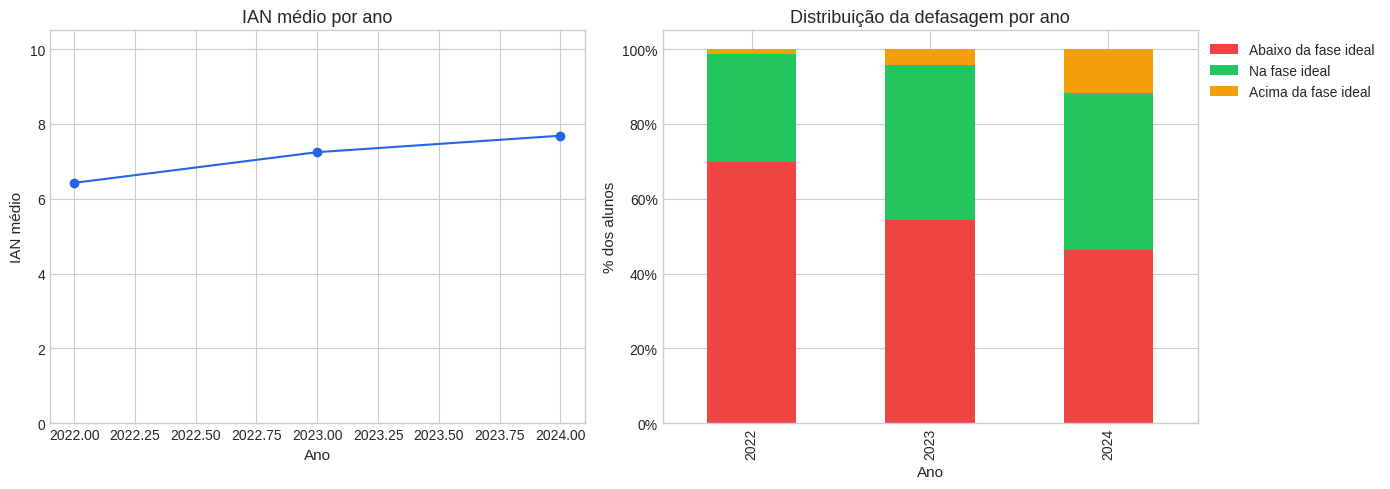


**Leitura analítica:** o IAN médio saiu de **6.42** em 2022 para **7.68** em 2024, variação de **+1.26 ponto(s)**. A proporção abaixo da fase ideal variou de **69.9%** para **46.2%**. Casos de defasagem severa (D < -2) caíram de **28** para **3** alunos entre 2022 e 2024. Para ML, `ian`, `defasagem`, `atraso_fase` e `status_defasagem` são candidatos fortes para explicar risco educacional — mas, como visto na Seção 5, `ian` é redundante com `defasagem` (é uma função direta dela).


In [8]:
ian_year = (
    base.groupby("ano")
    .agg(
        alunos=("ra", "count"),
        ian_medio=("ian", "mean"),
        ian_mediana=("ian", "median"),
        pct_ian_menor_7=("ian", lambda s: s.lt(7).mean()),
        defasagem_media=("defasagem", "mean"),
        pct_abaixo_fase=("defasagem", lambda s: s.lt(0).mean()),
        pct_na_fase=("defasagem", lambda s: s.eq(0).mean()),
        pct_acima_fase=("defasagem", lambda s: s.gt(0).mean()),
        alunos_defasagem_severa=("defasagem", lambda s: s.lt(-2).sum()),
    )
    .round(3)
)

display(ian_year)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ian_year["ian_medio"].plot(marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("IAN médio por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("IAN médio")
axes[0].set_ylim(0, 10.5)

defas_dist = (
    pd.crosstab(base["ano"], base["status_defasagem"], normalize="index")
    .reindex(columns=["Abaixo da fase ideal", "Na fase ideal", "Acima da fase ideal"])
    .fillna(0)
)
defas_dist.plot(kind="bar", stacked=True, ax=axes[1], color=["#ef4444", "#22c55e", "#f59e0b"])
axes[1].set_title("Distribuição da defasagem por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("% dos alunos")
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

delta_ian_22_24 = ian_year.loc[2024, "ian_medio"] - ian_year.loc[2022, "ian_medio"]
delta_abaixo_22_24 = ian_year.loc[2024, "pct_abaixo_fase"] - ian_year.loc[2022, "pct_abaixo_fase"]

display(Markdown(f'''
**Leitura analítica:** o IAN médio saiu de **{ian_year.loc[2022, "ian_medio"]:.2f}** em 2022 para **{ian_year.loc[2024, "ian_medio"]:.2f}** em 2024, variação de **{delta_ian_22_24:+.2f} ponto(s)**. A proporção abaixo da fase ideal variou de **{pct_fmt(ian_year.loc[2022, "pct_abaixo_fase"])}** para **{pct_fmt(ian_year.loc[2024, "pct_abaixo_fase"])}**. Casos de defasagem severa (D < -2) caíram de **{int(ian_year.loc[2022, "alunos_defasagem_severa"])}** para **{int(ian_year.loc[2024, "alunos_defasagem_severa"])}** alunos entre 2022 e 2024. Para ML, `ian`, `defasagem`, `atraso_fase` e `status_defasagem` são candidatos fortes para explicar risco educacional — mas, como visto na Seção 5, `ian` é redundante com `defasagem` (é uma função direta dela).
'''))


## 9. IDA — Desempenho acadêmico por ano e fase

**Pergunta 2:** o desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?


,alunos_com_ida,ida_medio,ida_mediana,inde_medio,mat_medio,por_medio,ing_medio,delta_ida_vs_ano_anterior,status_tendencia
ano,,,,,,,,,
2022,860,6.093,6.300,7.036,5.807,6.321,5.881,NaN,sem comparação
2023,937,6.663,6.800,7.342,6.410,6.817,6.200,0.570,melhorando
2024,1055,6.351,6.750,7.397,6.230,6.176,6.596,-0.312,caindo


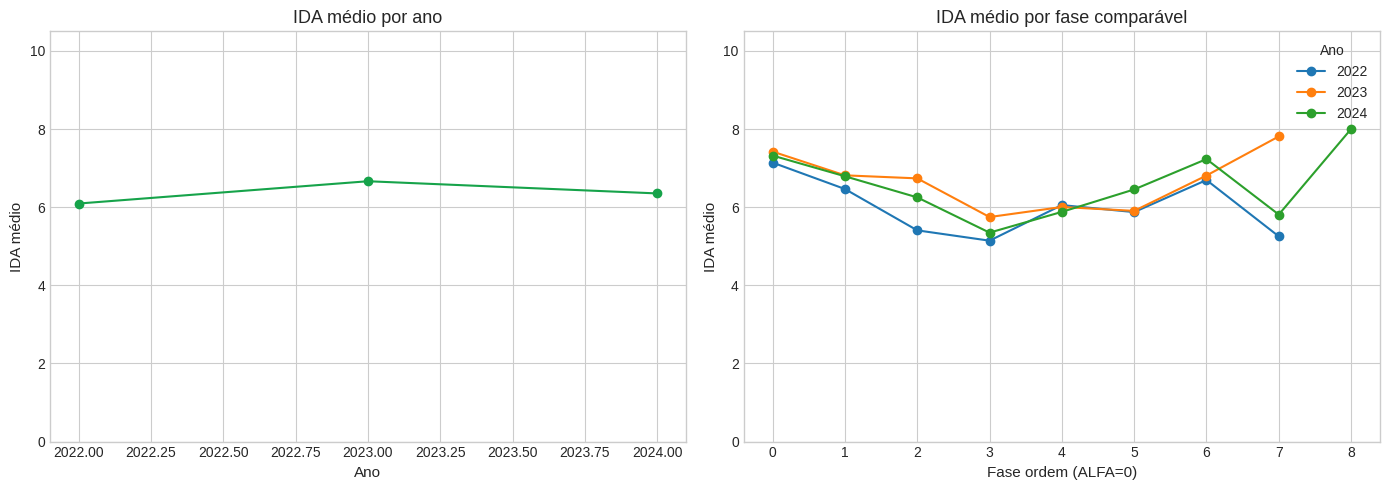


**Leitura analítica:** de 2023 para 2024 o IDA ficou **caindo** (-0.31). A visão por `fase_ordem` ajuda a separar efeito de ano de efeito de composição da turma/fase. Vale notar que a Nota de Inglês tem alta ausência (59% a 67% conforme o ano, ver Seção 4), então o IDA de boa parte dos alunos provavelmente é calculado só com Matemática e Português.


In [9]:
ida_year = (
    base.groupby("ano")
    .agg(
        alunos_com_ida=("ida", "count"),
        ida_medio=("ida", "mean"),
        ida_mediana=("ida", "median"),
        inde_medio=("inde", "mean"),
        mat_medio=("mat", "mean"),
        por_medio=("por", "mean"),
        ing_medio=("ing", "mean"),
    )
)
ida_year["delta_ida_vs_ano_anterior"] = ida_year["ida_medio"].diff()
ida_year["status_tendencia"] = ida_year["delta_ida_vs_ano_anterior"].map(classifica_tendencia)
display(ida_year.round(3))

fase_year = (
    base.dropna(subset=["fase_ordem"])
    .groupby(["ano", "fase_ordem"])
    .agg(alunos=("ra", "count"), ida_medio=("ida", "mean"), inde_medio=("inde", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ida_year["ida_medio"].plot(marker="o", ax=axes[0], color="#16a34a")
axes[0].set_title("IDA médio por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("IDA médio")
axes[0].set_ylim(0, 10.5)

for ano, group in fase_year.groupby("ano"):
    axes[1].plot(group["fase_ordem"], group["ida_medio"], marker="o", label=str(ano))
axes[1].set_title("IDA médio por fase comparável")
axes[1].set_xlabel("Fase ordem (ALFA=0)")
axes[1].set_ylabel("IDA médio")
axes[1].set_ylim(0, 10.5)
axes[1].legend(title="Ano")
plt.tight_layout()
plt.show()

delta_23_24 = ida_year.loc[2024, "ida_medio"] - ida_year.loc[2023, "ida_medio"]
display(Markdown(f'''
**Leitura analítica:** de 2023 para 2024 o IDA ficou **{classifica_tendencia(delta_23_24)}** ({delta_23_24:+.2f}). A visão por `fase_ordem` ajuda a separar efeito de ano de efeito de composição da turma/fase. Vale notar que a Nota de Inglês tem alta ausência (59% a 67% conforme o ano, ver Seção 4), então o IDA de boa parte dos alunos provavelmente é calculado só com Matemática e Português.
'''))


## 10. IEG — Engajamento versus IDA e IPV

**Pergunta 3:** o grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?


,corr_ieg_ida,corr_ieg_ipv,corr_ieg_inde
ano,,,
2022,0.564,0.589,0.802
2023,0.461,0.449,0.646
2024,0.538,0.535,0.787


alunos  ida_medio  ipv_medio  inde_medio
ano  quartil_ieg                                          
2022 Q1 baixo        257      4.626      6.459       6.013
     Q2              250      6.286      7.293       7.121
     Q3              232      6.906      7.713       7.608
     Q4 alto         121      7.252      7.978       7.938
2023 Q1 baixo        103      5.130      7.280       6.178
     Q2              273      6.222      7.684       6.961
     Q3              286      6.866      8.117       7.529
     Q4 alto         276      7.457      8.555       7.958
2024 Q1 baixo        386      4.821      6.567       6.322
     Q2              244      6.117      7.233       7.241
     Q3              232      6.957      7.636       7.814
     Q4 alto         294      7.551      7.993       8.234

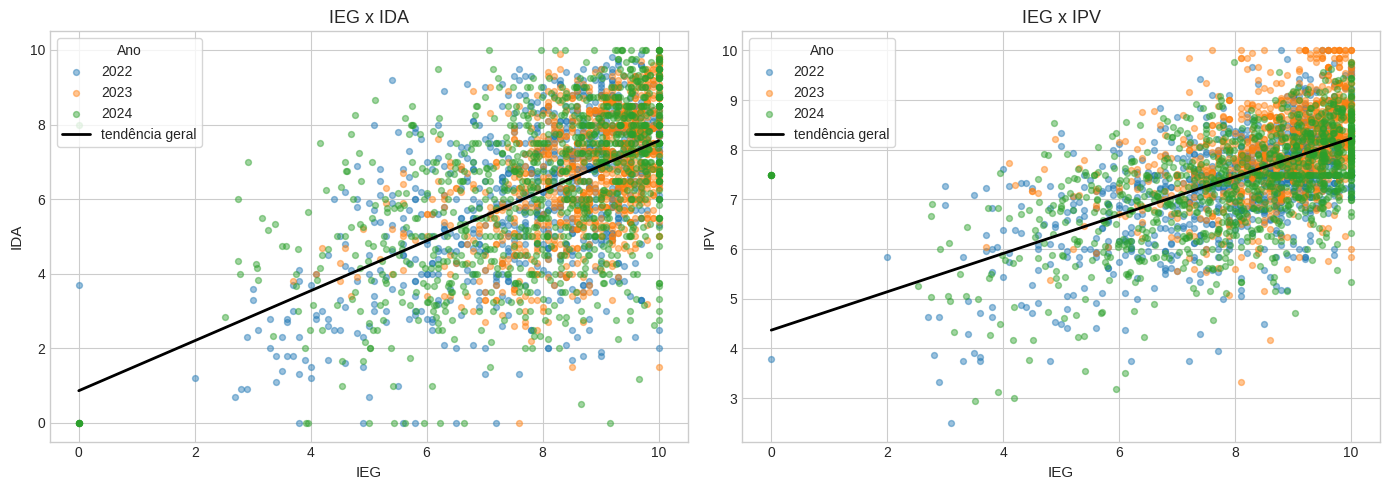


**Leitura analítica:** a correlação geral entre `IEG` e `IDA` é **0.54**; entre `IEG` e `IPV`, **0.56**. A relação é positiva e consistente nos 3 anos (ver tabela por ano acima), o que sugere que engajamento é um bom candidato tanto para explicar desempenho quanto para antecipar ponto de virada — sem assumir causalidade.


In [10]:
corr_ieg = []
for ano, group in base.groupby("ano"):
    corr = group[["ieg", "ida", "ipv", "inde"]].corr(numeric_only=True).loc["ieg", ["ida", "ipv", "inde"]]
    corr_ieg.append({"ano": ano, "corr_ieg_ida": corr["ida"], "corr_ieg_ipv": corr["ipv"], "corr_ieg_inde": corr["inde"]})
corr_ieg = pd.DataFrame(corr_ieg).set_index("ano")
display(corr_ieg.round(3))

quartil_ieg = base.dropna(subset=["ieg"]).copy()
quartil_ieg["quartil_ieg"] = pd.qcut(
    quartil_ieg["ieg"],
    q=4,
    labels=["Q1 baixo", "Q2", "Q3", "Q4 alto"],
    duplicates="drop",
)
quartil_ieg_summary = (
    quartil_ieg.groupby(["ano", "quartil_ieg"], observed=True)
    .agg(alunos=("ra", "count"), ida_medio=("ida", "mean"), ipv_medio=("ipv", "mean"), inde_medio=("inde", "mean"))
    .round(3)
)
display(quartil_ieg_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_scatter_with_fit(base, "ieg", "ida", axes[0], "IEG x IDA")
plot_scatter_with_fit(base, "ieg", "ipv", axes[1], "IEG x IPV")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**Leitura analítica:** a correlação geral entre `IEG` e `IDA` é **{base[["ieg", "ida"]].corr().iloc[0, 1]:.2f}**; entre `IEG` e `IPV`, **{base[["ieg", "ipv"]].corr().iloc[0, 1]:.2f}**. A relação é positiva e consistente nos 3 anos (ver tabela por ano acima), o que sugere que engajamento é um bom candidato tanto para explicar desempenho quanto para antecipar ponto de virada — sem assumir causalidade.
'''))


## 11. IAA — Coerência entre autoavaliação, desempenho e engajamento

**Pergunta 4:** as percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?


coerencia_iaa_ida,Coerente,IAA abaixo do desempenho,IAA acima do desempenho
ano,,,
2022,33.400,5.000,61.600
2023,33.600,21.500,44.900
2024,35.600,3.600,60.800


,iaa_medio,ida_medio,ieg_medio,gap_iaa_ida_medio,pct_iaa_zero
ano,,,,,
2022,8.274,6.093,7.891,2.182,4.535
2023,6.903,6.663,8.699,0.255,18.738
2024,8.544,6.351,7.375,2.194,1.730


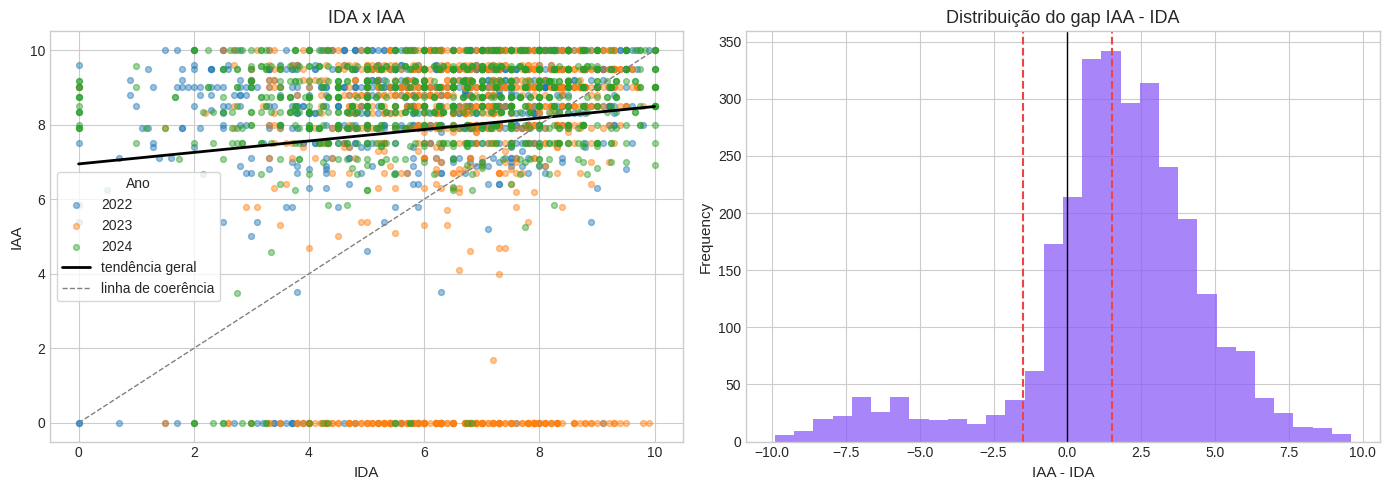


**Leitura analítica:** a correlação geral entre `IAA` e `IDA` é **0.12**; entre `IAA` e `IEG`, **0.13** — ambas fracas. Isso indica que a autopercepção do aluno tende a **não bater** com o desempenho medido objetivamente. Gaps positivos altos indicam alunos que se autoavaliam melhor do que o desempenho observado; gaps negativos altos indicam possível subestimação. Esse "gap" é, em si, uma boa feature para segmentação e para investigar risco de queda futura.


In [11]:
base["gap_iaa_ida"] = base["iaa"] - base["ida"]
base["gap_iaa_ieg"] = base["iaa"] - base["ieg"]


def faixa_gap(value, limite=1.5):
    if pd.isna(value):
        return np.nan
    if value > limite:
        return "IAA acima do desempenho"
    if value < -limite:
        return "IAA abaixo do desempenho"
    return "Coerente"


base["coerencia_iaa_ida"] = base["gap_iaa_ida"].map(faixa_gap)
base["coerencia_iaa_ieg"] = base["gap_iaa_ieg"].map(faixa_gap)

coerencia_ida = (
    pd.crosstab(base["ano"], base["coerencia_iaa_ida"], normalize="index")
    .mul(100)
    .round(1)
)
display(coerencia_ida)

gap_summary = (
    base.groupby("ano")
    .agg(
        iaa_medio=("iaa", "mean"),
        ida_medio=("ida", "mean"),
        ieg_medio=("ieg", "mean"),
        gap_iaa_ida_medio=("gap_iaa_ida", "mean"),
        pct_iaa_zero=("iaa", lambda s: s.eq(0).mean() * 100),
    )
    .round(3)
)
display(gap_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_scatter_with_fit(base, "ida", "iaa", axes[0], "IDA x IAA")
axes[0].plot([0, 10], [0, 10], linestyle="--", color="gray", linewidth=1, label="linha de coerência")
axes[0].legend(title="Ano", frameon=True)

base["gap_iaa_ida"].dropna().plot(kind="hist", bins=30, ax=axes[1], color="#8b5cf6", alpha=0.75)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(1.5, color="#ef4444", linestyle="--")
axes[1].axvline(-1.5, color="#ef4444", linestyle="--")
axes[1].set_title("Distribuição do gap IAA - IDA")
axes[1].set_xlabel("IAA - IDA")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**Leitura analítica:** a correlação geral entre `IAA` e `IDA` é **{base[["iaa", "ida"]].corr().iloc[0, 1]:.2f}**; entre `IAA` e `IEG`, **{base[["iaa", "ieg"]].corr().iloc[0, 1]:.2f}** — ambas fracas. Isso indica que a autopercepção do aluno tende a **não bater** com o desempenho medido objetivamente. Gaps positivos altos indicam alunos que se autoavaliam melhor do que o desempenho observado; gaps negativos altos indicam possível subestimação. Esse "gap" é, em si, uma boa feature para segmentação e para investigar risco de queda futura.
'''))


## 12. IPS — Sinais psicossociais antes de queda de IDA ou IEG

**Pergunta 5:** há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

Como a base é anual, "antecede" aqui significa: indicador no ano atual (t) versus queda no ano seguinte (t+1). A análise usa apenas alunos que aparecem em anos consecutivos — esse mesmo painel (`panel`) é reaproveitado nas Seções 14 (Pedra) e 15 (discussão de ML).


**Comparação por queda futura de IDA >= 1 ponto:**

,alunos,ips_medio,ida_atual,ieg_atual,delta_ida_prox,delta_ieg_prox
queda_ida_prox,,,,,,
False,917,6.061,6.380,8.526,0.674,-0.167
True,386,5.723,7.326,8.782,-2.191,-0.972


**Comparação por queda futura de IEG >= 1 ponto:**

,alunos,ips_medio,ida_atual,ieg_atual,delta_ida_prox,delta_ieg_prox
queda_ieg_prox,,,,,,
False,1000,6.109,6.765,8.548,0.061,0.271
True,303,5.473,6.333,8.781,-1.098,-2.583


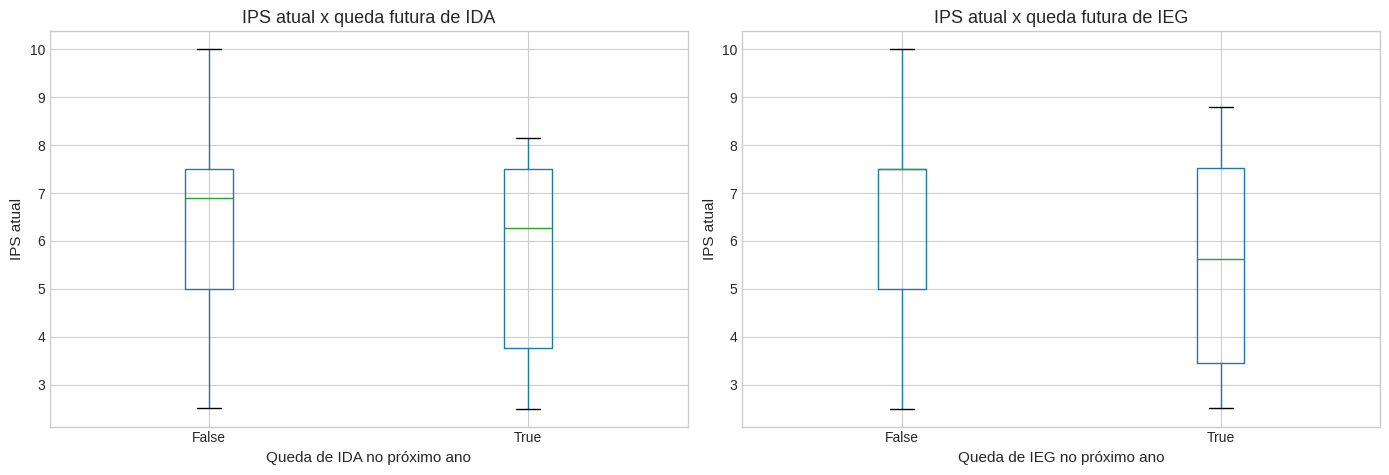


**Leitura analítica:** a análise longitudinal usa **897 alunos** com pelo menos um par de anos consecutivos. A diferença de `IPS` médio entre quem cai e quem não cai é pequena — na base atual, `IPS` isoladamente **não antecipa linearmente** quedas de desempenho/engajamento (correlação simultânea com IDA/IEG também é baixa, 0,00 a 0,13 conforme o ano). Provavelmente funciona melhor como parte de um sinal composto (`IPS` + `IDA` + `IEG` + histórico do próprio aluno) do que como preditor isolado.


In [12]:
panel = base.sort_values(["ra", "ano"]).copy()
for metric in ["ida", "ieg", "ips", "ipp", "ipv", "inde", "defasagem"]:
    panel[f"{metric}_next"] = panel.groupby("ra")[metric].shift(-1)
    panel[f"delta_{metric}_next"] = panel[f"{metric}_next"] - panel[metric]
panel["ano_next"] = panel.groupby("ra")["ano"].shift(-1)
panel["tem_ano_consecutivo"] = panel["ano_next"].eq(panel["ano"] + 1)
panel["queda_ida_prox"] = panel["tem_ano_consecutivo"] & panel["delta_ida_next"].le(-1)
panel["queda_ieg_prox"] = panel["tem_ano_consecutivo"] & panel["delta_ieg_next"].le(-1)

panel_valid = panel[panel["tem_ano_consecutivo"]].copy()


def compare_signal(outcome):
    d = panel_valid.dropna(subset=["ips", outcome])
    return (
        d.groupby(outcome)
        .agg(
            alunos=("ra", "count"),
            ips_medio=("ips", "mean"),
            ida_atual=("ida", "mean"),
            ieg_atual=("ieg", "mean"),
            delta_ida_prox=("delta_ida_next", "mean"),
            delta_ieg_prox=("delta_ieg_next", "mean"),
        )
        .round(3)
    )


display(Markdown("**Comparação por queda futura de IDA >= 1 ponto:**"))
display(compare_signal("queda_ida_prox"))
display(Markdown("**Comparação por queda futura de IEG >= 1 ponto:**"))
display(compare_signal("queda_ieg_prox"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
panel_valid.dropna(subset=["ips", "queda_ida_prox"]).boxplot(column="ips", by="queda_ida_prox", ax=axes[0])
axes[0].set_title("IPS atual x queda futura de IDA")
axes[0].set_xlabel("Queda de IDA no próximo ano")
axes[0].set_ylabel("IPS atual")
panel_valid.dropna(subset=["ips", "queda_ieg_prox"]).boxplot(column="ips", by="queda_ieg_prox", ax=axes[1])
axes[1].set_title("IPS atual x queda futura de IEG")
axes[1].set_xlabel("Queda de IEG no próximo ano")
axes[1].set_ylabel("IPS atual")
plt.suptitle("")
plt.tight_layout()
plt.show()

display(Markdown(f'''
**Leitura analítica:** a análise longitudinal usa **{panel_valid["ra"].nunique():,} alunos** com pelo menos um par de anos consecutivos. A diferença de `IPS` médio entre quem cai e quem não cai é pequena — na base atual, `IPS` isoladamente **não antecipa linearmente** quedas de desempenho/engajamento (correlação simultânea com IDA/IEG também é baixa, 0,00 a 0,13 conforme o ano). Provavelmente funciona melhor como parte de um sinal composto (`IPS` + `IDA` + `IEG` + histórico do próprio aluno) do que como preditor isolado.
'''))


## 13. IPP — Confirma ou contradiz a defasagem do IAN?

**Pergunta 6:** as avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

Observação: `IPP` não está preenchido em 2022 na base disponibilizada; por isso essa análise concentra 2023 e 2024.


,ano,variavel,corr_ipp
4,2023,ipv,0.516
5,2023,inde,0.435
2,2023,ida,0.351
3,2023,ieg,0.244
1,2023,defasagem,0.190
0,2023,ian,0.095
10,2024,ipv,0.750
11,2024,inde,0.637
9,2024,ieg,0.409
8,2024,ida,0.395


perfil_ipp_defasagem,Alerta oculto: IPP baixo sem defasagem,Coerente sem risco aparente,Confirma risco: defasagem + IPP baixo,Contradição: defasagem com IPP bom,Zona intermediária
ano,,,,,
2023,3.500,33.700,5.300,43.500,14.000
2024,1.900,41.500,3.500,37.400,15.700


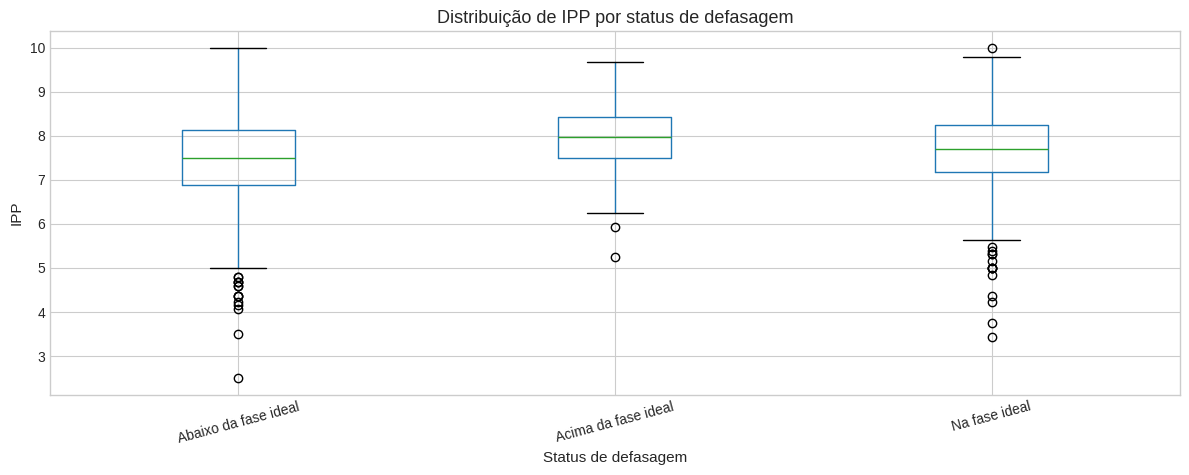


**Leitura analítica:** quando `IPP` baixo aparece junto com defasagem, há convergência de evidências. Quando há defasagem com `IPP` bom, a defasagem pode estar mais ligada à trajetória escolar/idade do que a uma limitação psicopedagógica. Quando `IPP` baixo aparece sem defasagem, surge um alerta preventivo — vale monitorar esse grupo mesmo sem sinal de atraso de fase.


In [13]:
ipp_cols = ["ipp", "ian", "defasagem", "ida", "ieg", "ipv", "inde"]
ipp_corr = corr_by_year(base.dropna(subset=["ipp"]), ipp_cols, "ipp")
display(ipp_corr.round(3))


def classifica_ipp_defas(row):
    if pd.isna(row["ipp"]) or pd.isna(row["defasagem"]):
        return np.nan
    tem_defasagem = row["defasagem"] < 0
    ipp_baixo = row["ipp"] < 6
    ipp_bom = row["ipp"] >= 7
    if tem_defasagem and ipp_baixo:
        return "Confirma risco: defasagem + IPP baixo"
    if tem_defasagem and ipp_bom:
        return "Contradição: defasagem com IPP bom"
    if not tem_defasagem and ipp_baixo:
        return "Alerta oculto: IPP baixo sem defasagem"
    if not tem_defasagem and ipp_bom:
        return "Coerente sem risco aparente"
    return "Zona intermediária"


base["perfil_ipp_defasagem"] = base.apply(classifica_ipp_defas, axis=1)
perfil_ipp = (
    pd.crosstab(base["ano"], base["perfil_ipp_defasagem"], normalize="index")
    .mul(100)
    .round(1)
)
display(perfil_ipp)

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = base.dropna(subset=["ipp", "status_defasagem"])
plot_df.boxplot(column="ipp", by="status_defasagem", ax=ax)
ax.set_title("Distribuição de IPP por status de defasagem")
ax.set_xlabel("Status de defasagem")
ax.set_ylabel("IPP")
plt.suptitle("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(Markdown('''
**Leitura analítica:** quando `IPP` baixo aparece junto com defasagem, há convergência de evidências. Quando há defasagem com `IPP` bom, a defasagem pode estar mais ligada à trajetória escolar/idade do que a uma limitação psicopedagógica. Quando `IPP` baixo aparece sem defasagem, surge um alerta preventivo — vale monitorar esse grupo mesmo sem sinal de atraso de fase.
'''))


## 14. IPV — Comportamentos associados ao ponto de virada

**Pergunta 7:** quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

Duas leituras: correlação simples e importância preditiva em Random Forest (poder preditivo dentro do próprio ano, não causalidade, e não é o modelo de risco da pergunta 9).


,ano,variavel,corr_ipv
0,2022,ida,0.617
1,2022,ieg,0.589
2,2022,iaa,0.256
3,2022,ips,0.208
6,2022,defasagem,0.173
5,2022,ian,0.111
7,2022,fase_ordem,-0.110
8,2022,idade,-0.195
4,2022,ipp,NaN
9,2023,ida,0.544


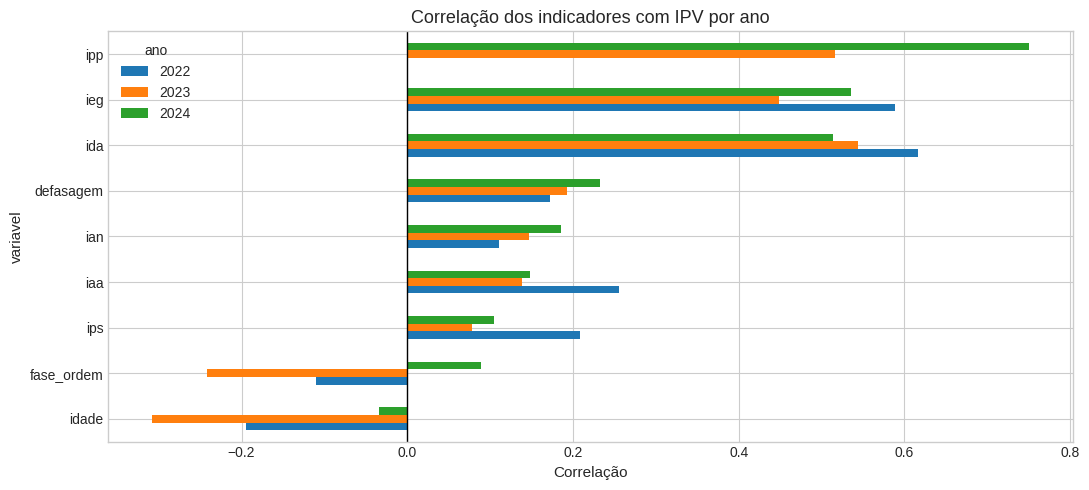

,modelo,linhas_modelo,MAE,R2
0,RandomForest IPV (exploratório),2852,0.514,0.598


,variavel,importancia,desvio
4,ipp,0.274,0.021
1,ieg,0.195,0.020
0,ida,0.179,0.022
3,ips,0.041,0.006
7,fase_ordem,0.010,0.003
2,iaa,0.005,0.003
8,idade,0.005,0.003
6,defasagem,0.002,0.001
5,ian,0.001,0.001


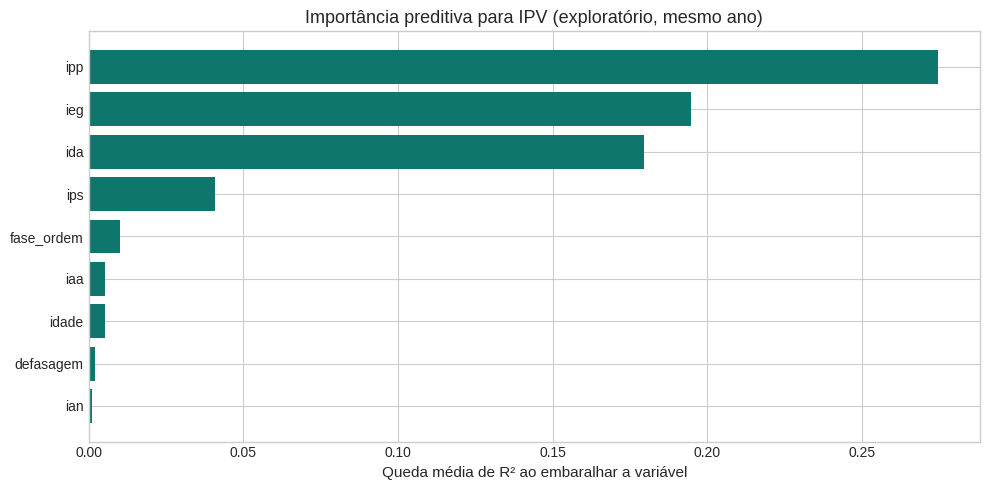


**Leitura analítica:** em geral, `IDA`, `IEG` e `IPP` aparecem como variáveis relevantes para explicar `IPV`. Este Random Forest é **exploratório** (mesmo ano, sem separação temporal) — serve para entender associação, não para prever o futuro. Para uma etapa de ML futura que preveja IPV do próximo ano, use apenas variáveis de anos anteriores (ver Seção 16).


In [14]:
features_ipv = ["ida", "ieg", "iaa", "ips", "ipp", "ian", "defasagem", "fase_ordem", "idade"]
corr_ipv = corr_by_year(base, features_ipv + ["ipv"], "ipv")
display(corr_ipv.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
corr_pivot = corr_ipv.pivot(index="variavel", columns="ano", values="corr_ipv").sort_values(2024, ascending=True)
corr_pivot.plot(kind="barh", ax=ax)
ax.set_title("Correlação dos indicadores com IPV por ano")
ax.set_xlabel("Correlação")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

if SKLEARN_OK:
    model_data_ipv = base.dropna(subset=["ipv"]).copy()
    X = model_data_ipv[features_ipv]
    y = model_data_ipv["ipv"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model_ipv = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)),
        ]
    )
    model_ipv.fit(X_train, y_train)
    pred = model_ipv.predict(X_test)
    perf_ipv = pd.DataFrame(
        [{"modelo": "RandomForest IPV (exploratório)", "linhas_modelo": len(model_data_ipv), "MAE": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)}]
    )
    display(perf_ipv.round(3))

    perm = permutation_importance(model_ipv, X_test, y_test, n_repeats=20, random_state=42)
    importance_ipv = (
        pd.DataFrame({"variavel": features_ipv, "importancia": perm.importances_mean, "desvio": perm.importances_std})
        .sort_values("importancia", ascending=False)
    )
    display(importance_ipv.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(importance_ipv["variavel"], importance_ipv["importancia"], color="#0f766e")
    ax.invert_yaxis()
    ax.set_title("Importância preditiva para IPV (exploratório, mesmo ano)")
    ax.set_xlabel("Queda média de R² ao embaralhar a variável")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(f"`sklearn` não está disponível neste kernel: {SKLEARN_ERROR}"))

display(Markdown('''
**Leitura analítica:** em geral, `IDA`, `IEG` e `IPP` aparecem como variáveis relevantes para explicar `IPV`. Este Random Forest é **exploratório** (mesmo ano, sem separação temporal) — serve para entender associação, não para prever o futuro. Para uma etapa de ML futura que preveja IPV do próximo ano, use apenas variáveis de anos anteriores (ver Seção 16).
'''))


## 15. INDE — Combinações multidimensionais que elevam a nota global

**Pergunta 8:** quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

Começamos com um **heatmap de correlação apenas dos indicadores** (não de todas as colunas numéricas da base, para manter a leitura focada), seguido de correlação por ano, importância preditiva e perfis combinados de `IDA + IEG + IPS + IPP`.


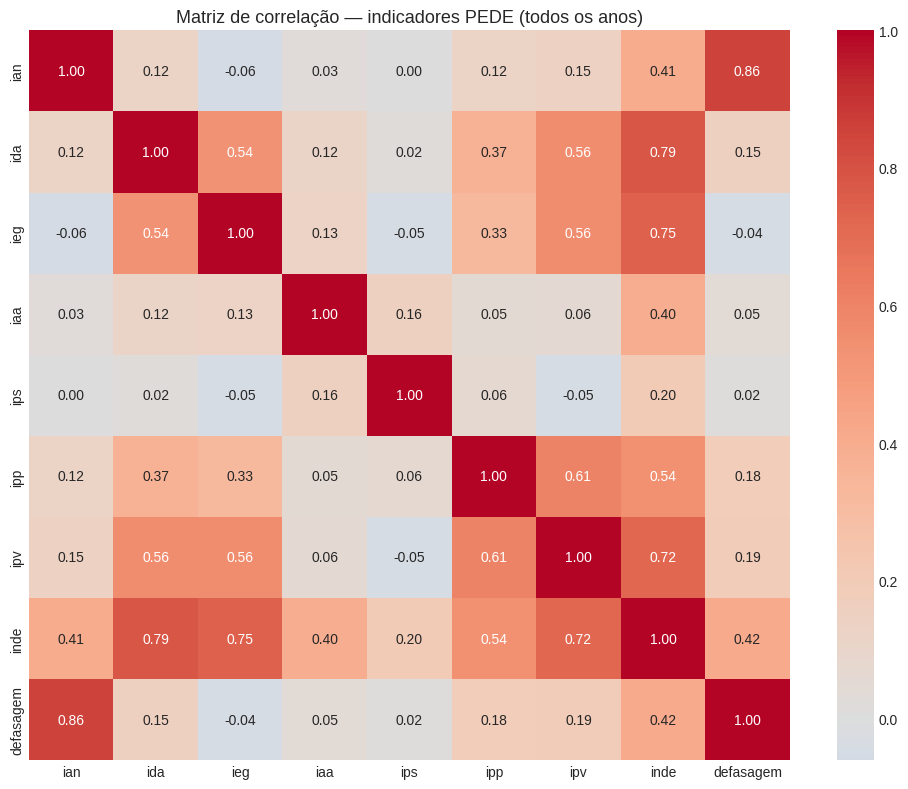

In [15]:
indicadores_heatmap = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde", "defasagem"]
corr_indicadores = base[indicadores_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_indicadores, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlação — indicadores PEDE (todos os anos)")
plt.tight_layout()
plt.show()


,ano,variavel,corr_inde
1,2022,ida,0.818
2,2022,ieg,0.802
6,2022,ipv,0.789
3,2022,iaa,0.455
7,2022,defasagem,0.407
0,2022,ian,0.395
4,2022,ips,0.269
8,2022,fase_ordem,-0.182
9,2022,idade,-0.341
5,2022,ipp,NaN


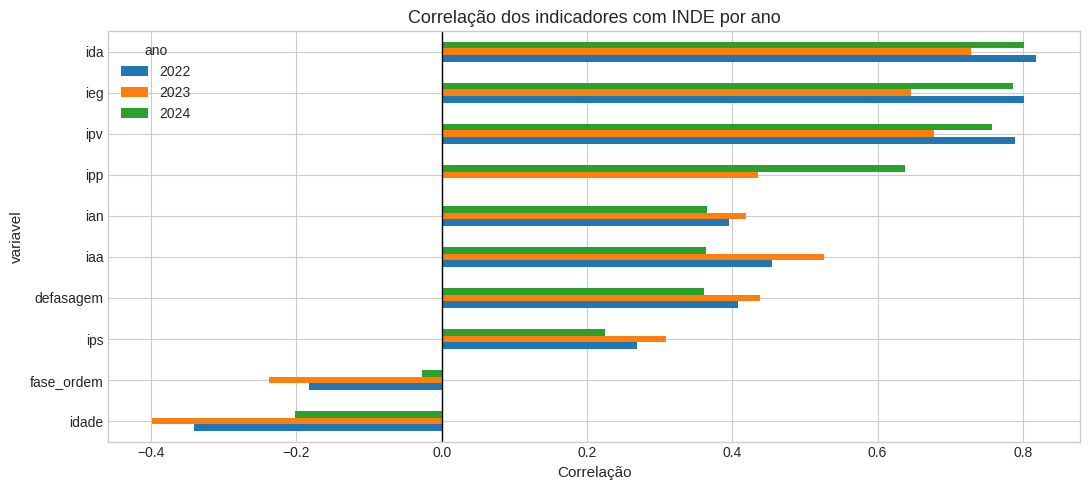

,modelo,linhas_modelo,MAE,R2
0,RandomForest INDE (exploratório),2845,0.135,0.962


,variavel,importancia,desvio
1,ida,0.382,0.017
2,ieg,0.225,0.010
3,iaa,0.103,0.005
6,ipv,0.086,0.004
4,ips,0.036,0.002
0,ian,0.035,0.003
7,defasagem,0.030,0.002
5,ipp,0.003,0.000
9,idade,0.000,0.000
8,fase_ordem,0.000,0.000


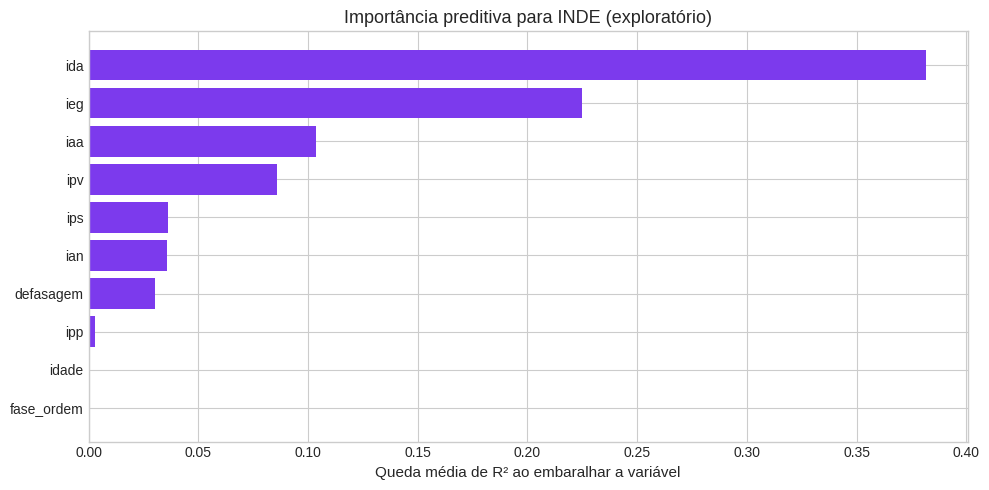

,alunos,inde_medio,ida_medio,ieg_medio,ips_medio,ipp_medio
combo_ida_ieg_ips_ipp,,,,,,
IDA alto (>=8) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),133,8.569,8.889,9.440,7.194,8.696
IDA alto (>=8) | IEG alto (>=8) | IPS médio (6-8) | IPP médio (6-8),118,8.321,8.726,9.313,7.158,7.409
IDA médio (6-8) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),126,8.142,7.212,9.323,7.246,8.446
IDA alto (>=8) | IEG alto (>=8) | IPS baixo (<6) | IPP alto (>=8),64,8.112,8.855,9.332,3.686,8.771
IDA alto (>=8) | IEG alto (>=8) | IPS baixo (<6) | IPP médio (6-8),46,7.940,8.788,9.336,3.763,7.312
IDA médio (6-8) | IEG alto (>=8) | IPS médio (6-8) | IPP médio (6-8),205,7.826,7.169,9.202,7.224,7.430
IDA médio (6-8) | IEG alto (>=8) | IPS baixo (<6) | IPP alto (>=8),97,7.694,7.108,9.351,3.462,8.519
IDA baixo (<6) | IEG alto (>=8) | IPS médio (6-8) | IPP alto (>=8),32,7.649,4.867,9.223,7.336,8.361
IDA médio (6-8) | IEG médio (6-8) | IPS médio (6-8) | IPP alto (>=8),24,7.525,6.990,7.285,7.330,8.365


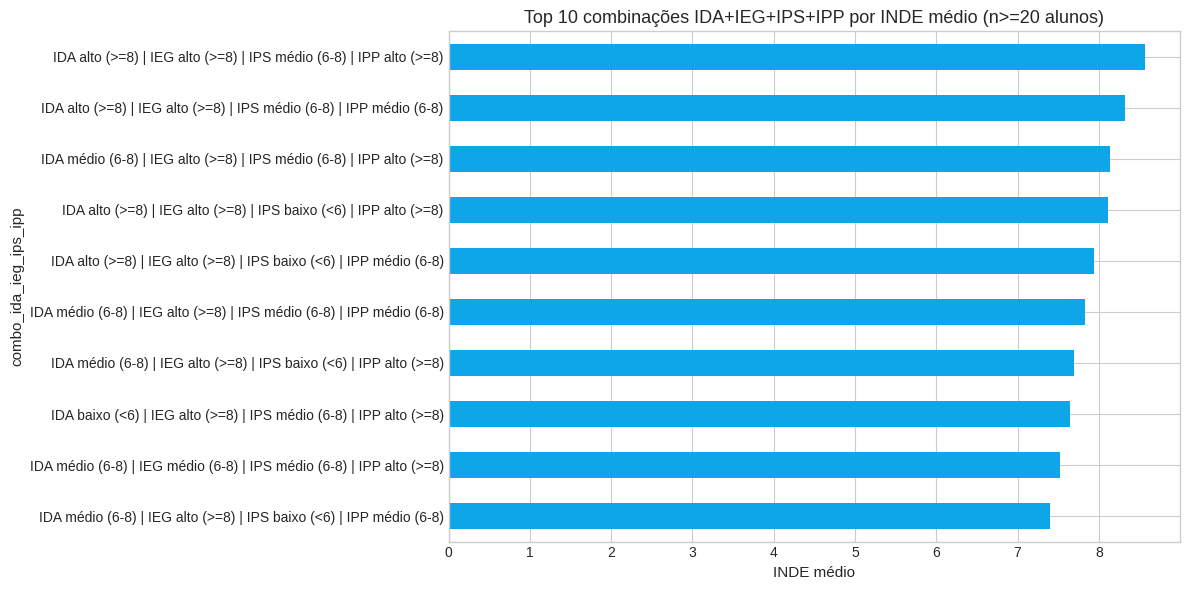


**Leitura analítica:** pela fórmula oficial (Seção 5), `IDA`, `IEG` e `IPV` têm o maior peso nominal sobre o `INDE` nas Fases 0-7 (0,20 cada); na Fase 8 o peso de `IDA` dobra (0,40) e `IPP`/`IPV` saem da conta. A importância por permutação e a tabela de combinações ajudam a ver se, na prática, algum componente domina mais que o peso nominal sugere — em geral as combinações com todos os componentes "alto" concentram o maior INDE médio, como esperado pela fórmula.


In [16]:
features_inde = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "defasagem", "fase_ordem", "idade"]
corr_inde = corr_by_year(base, features_inde + ["inde"], "inde")
display(corr_inde.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
corr_inde_pivot = corr_inde.pivot(index="variavel", columns="ano", values="corr_inde").sort_values(2024, ascending=True)
corr_inde_pivot.plot(kind="barh", ax=ax)
ax.set_title("Correlação dos indicadores com INDE por ano")
ax.set_xlabel("Correlação")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

if SKLEARN_OK:
    model_data_inde = base.dropna(subset=["inde"]).copy()
    X = model_data_inde[features_inde]
    y = model_data_inde["inde"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model_inde = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)),
        ]
    )
    model_inde.fit(X_train, y_train)
    pred = model_inde.predict(X_test)
    perf_inde = pd.DataFrame(
        [{"modelo": "RandomForest INDE (exploratório)", "linhas_modelo": len(model_data_inde), "MAE": mean_absolute_error(y_test, pred), "R2": r2_score(y_test, pred)}]
    )
    display(perf_inde.round(3))

    perm = permutation_importance(model_inde, X_test, y_test, n_repeats=20, random_state=42)
    importance_inde = (
        pd.DataFrame({"variavel": features_inde, "importancia": perm.importances_mean, "desvio": perm.importances_std})
        .sort_values("importancia", ascending=False)
    )
    display(importance_inde.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(importance_inde["variavel"], importance_inde["importancia"], color="#7c3aed")
    ax.invert_yaxis()
    ax.set_title("Importância preditiva para INDE (exploratório)")
    ax.set_xlabel("Queda média de R² ao embaralhar a variável")
    plt.tight_layout()
    plt.show()

combo_cols = ["ida", "ieg", "ips", "ipp"]
combo_df = base.dropna(subset=["inde"] + combo_cols).copy()
for col in combo_cols:
    combo_df[f"{col}_faixa"] = pd.cut(
        combo_df[col],
        bins=[-np.inf, 6, 8, np.inf],
        labels=["baixo (<6)", "médio (6-8)", "alto (>=8)"],
    )

combo_df["combo_ida_ieg_ips_ipp"] = combo_df[[f"{col}_faixa" for col in combo_cols]].astype(str).agg(
    lambda row: " | ".join([f"{col.upper()} {row[f'{col}_faixa']}" for col in combo_cols]),
    axis=1,
)

combo_summary = (
    combo_df.groupby("combo_ida_ieg_ips_ipp")
    .agg(
        alunos=("ra", "count"),
        inde_medio=("inde", "mean"),
        ida_medio=("ida", "mean"),
        ieg_medio=("ieg", "mean"),
        ips_medio=("ips", "mean"),
        ipp_medio=("ipp", "mean"),
    )
    .query("alunos >= 20")
    .sort_values("inde_medio", ascending=False)
    .round(3)
)
display(combo_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 6))
combo_summary.head(10).sort_values("inde_medio")["inde_medio"].plot(kind="barh", ax=ax, color="#0ea5e9")
ax.set_title("Top 10 combinações IDA+IEG+IPS+IPP por INDE médio (n>=20 alunos)")
ax.set_xlabel("INDE médio")
plt.tight_layout()
plt.show()

display(Markdown('''
**Leitura analítica:** pela fórmula oficial (Seção 5), `IDA`, `IEG` e `IPV` têm o maior peso nominal sobre o `INDE` nas Fases 0-7 (0,20 cada); na Fase 8 o peso de `IDA` dobra (0,40) e `IPP`/`IPV` saem da conta. A importância por permutação e a tabela de combinações ajudam a ver se, na prática, algum componente domina mais que o peso nominal sugere — em geral as combinações com todos os componentes "alto" concentram o maior INDE médio, como esperado pela fórmula.
'''))


## 16. Efetividade do programa — transição de Pedra ao longo do ciclo

**Pergunta 10:** os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

Esta seção não existia na primeira versão da EDA. Comparar a média de INDE por Pedra a cada ano isoladamente mistura "alunos novos entrando" com "evolução de quem já estava" — por isso construímos uma **matriz de transição de Pedra** usando o mesmo painel de alunos com anos consecutivos (`panel`, Seção 12), que isola melhor o efeito de evolução real.


**Movimentos de faixa entre anos consecutivos (1,248 pares aluno-ano):**

,% dos pares
movimento,
Manteve faixa,50.600
Desceu de faixa,25.200
Subiu de faixa,24.300


**Matriz de transição (linha = Pedra no ano t, coluna = Pedra no ano t+1):**

pedra_next,Quartzo,Ágata,Ametista,Topázio
pedra,,,,
Quartzo,37,43,10,0
Ágata,57,145,89,18
Ametista,30,117,265,143
Topázio,2,14,94,184


**Matriz de transição em % (por linha):**

pedra_next,Quartzo,Ágata,Ametista,Topázio
pedra,,,,
Quartzo,41.100,47.800,11.100,0.000
Ágata,18.400,46.900,28.800,5.800
Ametista,5.400,21.100,47.700,25.800
Topázio,0.700,4.800,32.000,62.600


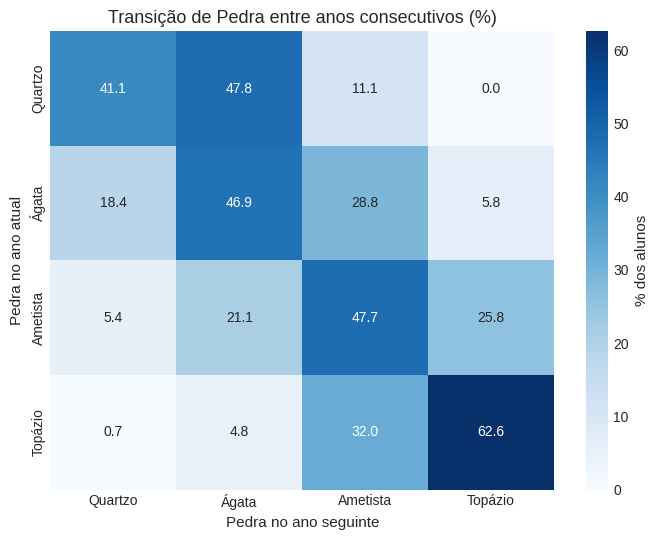

**INDE médio por Pedra e ano (visão de nível, não de evolução individual):**

pedra,Quartzo,Ágata,Ametista,Topázio
ano,,,,
2022,5.243,6.606,7.528,8.367
2023,5.550,6.569,7.511,8.441
2024,5.400,6.600,7.534,8.468


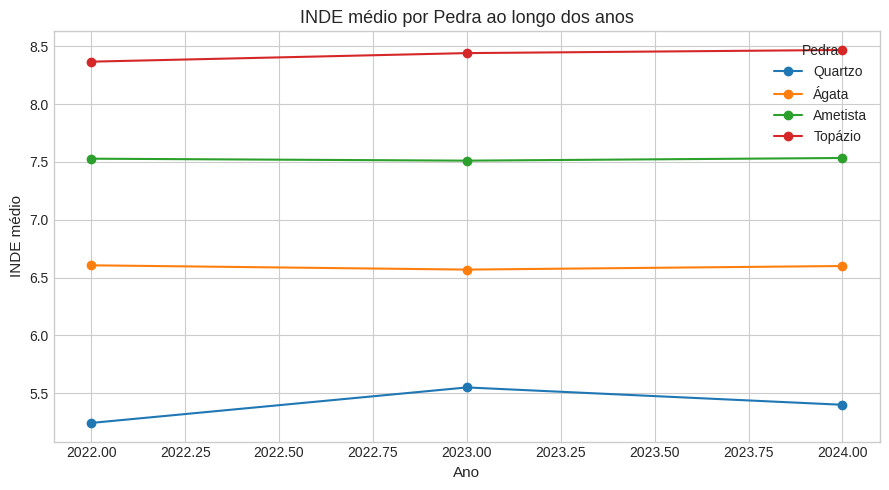


**Leitura analítica:** entre alunos com anos consecutivos, **24.3%** subiram de faixa, **50.6%** mantiveram a mesma faixa e **25.2%** desceram de faixa. Isso é uma leitura mais direta de efetividade do que comparar médias de INDE por Pedra ano a ano (que mistura entrada de alunos novos com evolução real). A matriz de transição mostra especificamente onde a saída de faixa é mais comum — por exemplo, se `Ágata` perde mais alunos para `Quartzo` do que ganha de outras faixas, isso pede atenção pedagógica específica para esse grupo. O INDE médio por Pedra, por sua vez, se mantém relativamente estável ano a ano dentro de cada faixa — o que é esperado, já que a própria definição de Pedra é uma faixa de INDE (ver `02_Base_Conhecimento_PEDE.md`, seção 3).


In [17]:
pedra_order = ["Quartzo", "Ágata", "Ametista", "Topázio"]
pedra_rank = {p: i for i, p in enumerate(pedra_order)}

pedra_panel = base[base["pedra"].isin(pedra_order)].sort_values(["ra", "ano"]).copy()
pedra_panel["pedra_rank"] = pedra_panel["pedra"].map(pedra_rank)
pedra_panel["pedra_next"] = pedra_panel.groupby("ra")["pedra"].shift(-1)
pedra_panel["pedra_rank_next"] = pedra_panel.groupby("ra")["pedra_rank"].shift(-1)
pedra_panel["ano_next"] = pedra_panel.groupby("ra")["ano"].shift(-1)
pedra_panel["consecutivo"] = pedra_panel["ano_next"].eq(pedra_panel["ano"] + 1)

trans = pedra_panel[pedra_panel["consecutivo"] & pedra_panel["pedra_next"].notna()].copy()
trans["movimento"] = np.select(
    [
        trans["pedra_rank_next"] > trans["pedra_rank"],
        trans["pedra_rank_next"] < trans["pedra_rank"],
        trans["pedra_rank_next"] == trans["pedra_rank"],
    ],
    ["Subiu de faixa", "Desceu de faixa", "Manteve faixa"],
    default="Sem comparação",
)

display(Markdown(f"**Movimentos de faixa entre anos consecutivos ({len(trans):,} pares aluno-ano):**"))
movimento_summary = trans["movimento"].value_counts(normalize=True).mul(100).round(1).rename("% dos pares")
display(movimento_summary.to_frame())

display(Markdown("**Matriz de transição (linha = Pedra no ano t, coluna = Pedra no ano t+1):**"))
matriz_transicao = pd.crosstab(trans["pedra"], trans["pedra_next"]).reindex(index=pedra_order, columns=pedra_order)
display(matriz_transicao)

matriz_transicao_pct = matriz_transicao.div(matriz_transicao.sum(axis=1), axis=0).mul(100).round(1)
display(Markdown("**Matriz de transição em % (por linha):**"))
display(matriz_transicao_pct)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(matriz_transicao_pct, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% dos alunos"})
ax.set_title("Transição de Pedra entre anos consecutivos (%)")
ax.set_xlabel("Pedra no ano seguinte")
ax.set_ylabel("Pedra no ano atual")
plt.tight_layout()
plt.show()

inde_por_pedra = (
    base[base["pedra"].isin(pedra_order)]
    .groupby(["ano", "pedra"])["inde"]
    .mean()
    .unstack("pedra")
    .reindex(columns=pedra_order)
    .round(3)
)
display(Markdown("**INDE médio por Pedra e ano (visão de nível, não de evolução individual):**"))
display(inde_por_pedra)

fig, ax = plt.subplots(figsize=(9, 5))
inde_por_pedra.plot(marker="o", ax=ax)
ax.set_title("INDE médio por Pedra ao longo dos anos")
ax.set_xlabel("Ano")
ax.set_ylabel("INDE médio")
ax.legend(title="Pedra")
plt.tight_layout()
plt.show()

pct_subiu = movimento_summary.get("Subiu de faixa", 0)
pct_desceu = movimento_summary.get("Desceu de faixa", 0)
pct_manteve = movimento_summary.get("Manteve faixa", 0)

display(Markdown(f'''
**Leitura analítica:** entre alunos com anos consecutivos, **{pct_subiu:.1f}%** subiram de faixa, **{pct_manteve:.1f}%** mantiveram a mesma faixa e **{pct_desceu:.1f}%** desceram de faixa. Isso é uma leitura mais direta de efetividade do que comparar médias de INDE por Pedra ano a ano (que mistura entrada de alunos novos com evolução real). A matriz de transição mostra especificamente onde a saída de faixa é mais comum — por exemplo, se `Ágata` perde mais alunos para `Quartzo` do que ganha de outras faixas, isso pede atenção pedagógica específica para esse grupo. O INDE médio por Pedra, por sua vez, se mantém relativamente estável ano a ano dentro de cada faixa — o que é esperado, já que a própria definição de Pedra é uma faixa de INDE (ver `02_Base_Conhecimento_PEDE.md`, seção 3).
'''))


## 17. Machine Learning — caminhos possíveis para o alvo de risco (discussão, sem treinar modelo)

**Pergunta 9:** quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

Por combinação com o usuário, **esta etapa não treina nenhum modelo** — o objetivo aqui é mapear, com números reais da base, os caminhos possíveis para definir o **alvo (rótulo)** de um futuro modelo de risco, incluindo prós e contras de cada um. A ideia de usar o `INDE` diretamente como alvo é um caminho válido e é comparada aqui com alternativas baseadas em evento (queda ano a ano).


In [18]:
candidatos_alvo = []

# Caminho 1: INDE contínuo (nível, não evento)
n_inde_valido = base["inde"].notna().sum()
candidatos_alvo.append({
    "caminho": "1. INDE contínuo (regressão)",
    "tipo": "Nível (nota do próprio ano)",
    "n_disponivel": int(n_inde_valido),
    "observacao": "Alvo = valor do INDE. Simples e alinhado ao índice oficial da Associação.",
})

# Caminho 2: INDE/Pedra abaixo de limiar (classificação de nível)
pct_inde_baixo = (base["inde"] < 6).mean() * 100
candidatos_alvo.append({
    "caminho": "2. INDE < 6 ou Pedra Quartzo/Ágata baixa (classificação binária, nível)",
    "tipo": "Nível (nota do próprio ano)",
    "n_disponivel": int(n_inde_valido),
    "observacao": f"~{pct_inde_baixo:.1f}% dos aluno-ano ficam abaixo do limiar — desbalanceamento moderado, varia por ano (7% a 15%).",
})

# Caminho 3: eventos ano a ano (usa panel já calculado na Seção 12)
n_pares = len(panel_valid)
n_alunos_pares = panel_valid["ra"].nunique()
taxa_queda_ida = panel_valid["delta_ida_next"].le(-1).mean() * 100
taxa_aumento_defasagem = (panel_valid["delta_defasagem_next"] < 0).mean() * 100
taxa_composto = ((panel_valid["delta_ida_next"].le(-1)) | (panel_valid["delta_defasagem_next"] < 0)).mean() * 100

candidatos_alvo.append({
    "caminho": "3a. Queda de IDA >= 1 ponto no ano seguinte (evento)",
    "tipo": "Evento (variação t -> t+1)",
    "n_disponivel": int(n_pares),
    "observacao": f"{taxa_queda_ida:.1f}% dos {n_pares:,} pares aluno-ano consecutivos ({n_alunos_pares:,} alunos). Não-circular: mede mudança, não nível.",
})
candidatos_alvo.append({
    "caminho": "3b. Aumento de defasagem no ano seguinte (evento)",
    "tipo": "Evento (variação t -> t+1)",
    "n_disponivel": int(n_pares),
    "observacao": f"{taxa_aumento_defasagem:.1f}% dos pares. Alvo mais raro (desbalanceamento maior), direto ao IAN/defasagem.",
})
candidatos_alvo.append({
    "caminho": "3c. Risco composto: queda de IDA OU aumento de defasagem (evento)",
    "tipo": "Evento (variação t -> t+1)",
    "n_disponivel": int(n_pares),
    "observacao": f"{taxa_composto:.1f}% dos pares — classe positiva maior e mais balanceada, mas mistura dois fenômenos diferentes num só rótulo.",
})

candidatos_df = pd.DataFrame(candidatos_alvo)
display(candidatos_df)


,caminho,tipo,n_disponivel,observacao
0,1. INDE contínuo (regressão),Nível (nota do próprio ano),2845,Alvo = valor do INDE. Simples e alinhado ao ín...
1,2. INDE < 6 ou Pedra Quartzo/Ágata baixa (clas...,Nível (nota do próprio ano),2845,~10.4% dos aluno-ano ficam abaixo do limiar — ...
2,3a. Queda de IDA >= 1 ponto no ano seguinte (e...,Evento (variação t -> t+1),1365,"28.3% dos 1,365 pares aluno-ano consecutivos (..."
3,3b. Aumento de defasagem no ano seguinte (evento),Evento (variação t -> t+1),1365,17.3% dos pares. Alvo mais raro (desbalanceame...
4,3c. Risco composto: queda de IDA OU aumento de...,Evento (variação t -> t+1),1365,41.9% dos pares — classe positiva maior e mais...


In [19]:
display(Markdown('''
### Prós e contras de cada caminho

| Caminho | Prós | Contras / cuidados |
|---|---|---|
| **1. INDE contínuo** | Alvo já é a métrica oficial da Associação; fácil de comunicar; regressão dá granularidade fina. | Se as sub-notas (IAN, IDA, IEG...) entrarem como features, a "previsão" é quase circular — a fórmula do INDE já é conhecida (Seção 5), então o modelo tenderia a reaprender os pesos em vez de descobrir um padrão novo de risco. |
| **2. INDE/Pedra abaixo de limiar** | Vira um problema de classificação binária, fácil de interpretar como "risco: sim/não"; probabilidade sai naturalmente do `predict_proba`. | Mesmo problema de circularidade do caminho 1 se as sub-notas forem features; o limiar (6, ou faixa Quartzo/Ágata) é uma escolha de negócio que precisa ser validada com a Associação. |
| **3a. Queda de IDA no ano seguinte** | Mede *mudança*, não nível — não é circular; direto à pergunta "quem vai piorar"; usa dados de anos anteriores como features sem redundância óbvia. | Precisa do painel longitudinal (~{n_alunos} alunos com pelo menos 1 par de anos consecutivos) — menos linhas que o dataset completo; alvo restrito ao desempenho acadêmico, não pega defasagem nem aspectos psicossociais. |
| **3b. Aumento de defasagem** | Também não-circular; liga direto à dor de negócio "aumento da defasagem" citada no enunciado. | Classe positiva mais rara ({taxa_defas:.1f}%) — desbalanceamento maior, exige `class_weight`/reamostragem e métricas como PR-AUC/recall em vez de acurácia. |
| **3c. Risco composto (IDA cai OU defasagem aumenta)** | Classe positiva mais frequente ({taxa_comp:.1f}%) — mais fácil de modelar com menos dado; cobre duas dores de negócio ao mesmo tempo (desempenho e nível). | Mistura dois fenômenos diferentes num único rótulo — dificulta explicar *por que* o modelo marcou risco (queda de nota? atraso de fase? os dois?); pode exigir um rótulo multi-classe ou dois modelos separados no futuro.

**Recomendação para quando for construir o modelo:** os caminhos 3a/3b/3c (baseados em evento) tendem a ser mais robustos para responder literalmente "risco de queda no desempenho ou aumento da defasagem" (como pede o enunciado), por não serem circulares com a própria fórmula do INDE. O caminho 1/2 (INDE como alvo) continua válido, mas exige mais cuidado na escolha de features (ex.: não usar todas as sub-notas do mesmo ano, ou tratar como problema diferente: "o que prevê o INDE de alunos novos, sem histórico"). Essa decisão fica em aberto para a próxima etapa, com os números acima como referência.
'''.format(
    n_alunos=f"{n_alunos_pares:,}",
    taxa_defas=taxa_aumento_defasagem,
    taxa_comp=taxa_composto,
)))



### Prós e contras de cada caminho

| Caminho | Prós | Contras / cuidados |
|---|---|---|
| **1. INDE contínuo** | Alvo já é a métrica oficial da Associação; fácil de comunicar; regressão dá granularidade fina. | Se as sub-notas (IAN, IDA, IEG...) entrarem como features, a "previsão" é quase circular — a fórmula do INDE já é conhecida (Seção 5), então o modelo tenderia a reaprender os pesos em vez de descobrir um padrão novo de risco. |
| **2. INDE/Pedra abaixo de limiar** | Vira um problema de classificação binária, fácil de interpretar como "risco: sim/não"; probabilidade sai naturalmente do `predict_proba`. | Mesmo problema de circularidade do caminho 1 se as sub-notas forem features; o limiar (6, ou faixa Quartzo/Ágata) é uma escolha de negócio que precisa ser validada com a Associação. |
| **3a. Queda de IDA no ano seguinte** | Mede *mudança*, não nível — não é circular; direto à pergunta "quem vai piorar"; usa dados de anos anteriores como features sem redundância óbvia. | Precisa do painel longitudinal (~897 alunos com pelo menos 1 par de anos consecutivos) — menos linhas que o dataset completo; alvo restrito ao desempenho acadêmico, não pega defasagem nem aspectos psicossociais. |
| **3b. Aumento de defasagem** | Também não-circular; liga direto à dor de negócio "aumento da defasagem" citada no enunciado. | Classe positiva mais rara (17.3%) — desbalanceamento maior, exige `class_weight`/reamostragem e métricas como PR-AUC/recall em vez de acurácia. |
| **3c. Risco composto (IDA cai OU defasagem aumenta)** | Classe positiva mais frequente (41.9%) — mais fácil de modelar com menos dado; cobre duas dores de negócio ao mesmo tempo (desempenho e nível). | Mistura dois fenômenos diferentes num único rótulo — dificulta explicar *por que* o modelo marcou risco (queda de nota? atraso de fase? os dois?); pode exigir um rótulo multi-classe ou dois modelos separados no futuro.

**Recomendação para quando for construir o modelo:** os caminhos 3a/3b/3c (baseados em evento) tendem a ser mais robustos para responder literalmente "risco de queda no desempenho ou aumento da defasagem" (como pede o enunciado), por não serem circulares com a própria fórmula do INDE. O caminho 1/2 (INDE como alvo) continua válido, mas exige mais cuidado na escolha de features (ex.: não usar todas as sub-notas do mesmo ano, ou tratar como problema diferente: "o que prevê o INDE de alunos novos, sem histórico"). Essa decisão fica em aberto para a próxima etapa, com os números acima como referência.


## 18. Base analítica preparada para uma futura etapa de Machine Learning

Preparo de features para quando o alvo for decidido (Seção 17) — mantido da primeira versão da EDA, sem treinar modelo aqui.


In [20]:
ml_features = [
    "ano", "fase_ordem", "idade", "ano_ingresso",
    "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde",
    "defasagem", "atraso_fase", "gap_iaa_ida", "gap_iaa_ieg",
    "genero", "instituicao", "pedra", "status_defasagem", "situacao",
]

ml_base = base[ml_features].copy()
ml_base["risco_defasagem_nivel"] = ml_base["defasagem"].lt(0)
ml_base["baixo_inde_nivel"] = ml_base["inde"].lt(6)

feature_catalog = pd.DataFrame(
    [
        {"variavel": "ian / defasagem / atraso_fase", "tipo": "numérica", "uso_ml": "risco de defasagem e contexto de nível (ian é redundante com defasagem, ver Seção 5)"},
        {"variavel": "ida / mat / por / ing", "tipo": "numérica", "uso_ml": "desempenho acadêmico e tendência"},
        {"variavel": "ieg", "tipo": "numérica", "uso_ml": "engajamento, provável driver de IDA/IPV"},
        {"variavel": "iaa e gaps IAA-IDA/IEG", "tipo": "numérica derivada", "uso_ml": "coerência de autopercepção"},
        {"variavel": "ips", "tipo": "numérica", "uso_ml": "sinal psicossocial; fraco isoladamente, útil combinado"},
        {"variavel": "ipp", "tipo": "numérica", "uso_ml": "avaliação psicopedagógica; ausente em 2022"},
        {"variavel": "fase_ordem / idade / ano_ingresso", "tipo": "numérica", "uso_ml": "contexto de trajetória"},
        {"variavel": "genero / instituicao / pedra / situacao", "tipo": "categórica", "uso_ml": "segmentação e controles"},
    ]
)

display(feature_catalog)
display(ml_base.head())
display(
    ml_base.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("% nulos")
    .to_frame()
    .round(1)
)

display(Markdown('''
**Próximo passo (fora do escopo deste notebook):** decidir, com base na Seção 17, qual caminho de alvo usar; se for baseado em evento (3a/3b/3c), usar o `panel`/`panel_valid` já construído na Seção 12 como ponto de partida; sempre que o alvo for futuro, usar apenas variáveis do ano anterior como feature para evitar vazamento de dado (data leakage).
'''))


,variavel,tipo,uso_ml
0,ian / defasagem / atraso_fase,numérica,risco de defasagem e contexto de nível (ian é ...
1,ida / mat / por / ing,numérica,desempenho acadêmico e tendência
2,ieg,numérica,"engajamento, provável driver de IDA/IPV"
3,iaa e gaps IAA-IDA/IEG,numérica derivada,coerência de autopercepção
4,ips,numérica,"sinal psicossocial; fraco isoladamente, útil c..."
5,ipp,numérica,avaliação psicopedagógica; ausente em 2022
6,fase_ordem / idade / ano_ingresso,numérica,contexto de trajetória
7,genero / instituicao / pedra / situacao,categórica,segmentação e controles


,ano,fase_ordem,idade,ano_ingresso,ian,ida,ieg,iaa,ips,ipp,ipv,inde,defasagem,atraso_fase,gap_iaa_ida,gap_iaa_ieg,genero,instituicao,pedra,status_defasagem,situacao,risco_defasagem_nivel,baixo_inde_nivel
0,2022,7,19,2016,5.000,4.000,4.100,8.300,5.600,NaN,7.278,5.783,-1,1,4.300,4.200,Menina,Escola Pública,Quartzo,Abaixo da fase ideal,NaN,True,True
1,2022,7,17,2017,10.000,6.800,5.200,8.800,6.300,NaN,6.778,7.055,0,0,2.000,3.600,Menina,Rede Decisão,Ametista,Na fase ideal,NaN,False,False
2,2022,7,17,2016,10.000,5.600,7.900,0.000,5.600,NaN,7.556,6.591,0,0,-5.600,-7.900,Menina,Rede Decisão,Ágata,Na fase ideal,NaN,False,False
3,2022,7,17,2017,10.000,5.000,4.500,8.800,5.600,NaN,5.278,5.951,0,0,3.800,4.300,Menino,Rede Decisão,Quartzo,Na fase ideal,NaN,False,True
4,2022,7,17,2016,10.000,5.200,8.600,7.900,5.600,NaN,7.389,7.427,0,0,2.700,-0.700,Menina,Rede Decisão,Ametista,Na fase ideal,NaN,False,False


,% nulos
situacao,61.800
ipp,34.300
inde,6.100
gap_iaa_ida,5.900
ida,5.900
ipv,5.900
gap_iaa_ieg,5.900
ips,5.600
iaa,5.400
pedra,4.900



**Próximo passo (fora do escopo deste notebook):** decidir, com base na Seção 17, qual caminho de alvo usar; se for baseado em evento (3a/3b/3c), usar o `panel`/`panel_valid` já construído na Seção 12 como ponto de partida; sempre que o alvo for futuro, usar apenas variáveis do ano anterior como feature para evitar vazamento de dado (data leakage).


## 19. Resumo executivo

Consolidação das principais leituras numéricas de cada seção, incluindo as duas perguntas que não estavam cobertas na primeira versão da EDA (efetividade do programa e discussão do alvo de ML).


In [21]:
def safe_corr(a, b):
    return base[[a, b]].corr().iloc[0, 1]


resumo = pd.DataFrame(
    [
        {
            "tema": "IAN / Defasagem",
            "ponto_analitico": f"IAN médio 2024 = {ian_year.loc[2024, 'ian_medio']:.2f}; alunos abaixo da fase ideal = {pct_fmt(ian_year.loc[2024, 'pct_abaixo_fase'])}.",
        },
        {
            "tema": "IDA",
            "ponto_analitico": f"IDA de 2023 para 2024 está {classifica_tendencia(delta_23_24)} ({delta_23_24:+.2f}).",
        },
        {
            "tema": "IEG",
            "ponto_analitico": f"Correlação IEG-IDA = {safe_corr('ieg', 'ida'):.2f}; IEG-IPV = {safe_corr('ieg', 'ipv'):.2f}.",
        },
        {
            "tema": "IAA",
            "ponto_analitico": "Gaps IAA-IDA/IEG permitem identificar superestimação, subestimação e coerência de autopercepção; correlação simultânea é fraca.",
        },
        {
            "tema": "IPS",
            "ponto_analitico": f"Há {panel_valid['ra'].nunique():,} alunos com histórico em anos consecutivos; IPS isolado não antecipa linearmente quedas futuras.",
        },
        {
            "tema": "IPP",
            "ponto_analitico": "IPP é útil em 2023-2024 (correlação alta com IPV), mas ausente em 2022 — tratar com cuidado em comparações históricas.",
        },
        {
            "tema": "IPV / INDE",
            "ponto_analitico": f"Correlação geral IPV-INDE = {safe_corr('ipv', 'inde'):.2f}; IDA-INDE = {safe_corr('ida', 'inde'):.2f}; IEG-INDE = {safe_corr('ieg', 'inde'):.2f}.",
        },
        {
            "tema": "Efetividade do programa (Pedra)",
            "ponto_analitico": f"Entre pares de anos consecutivos: {pct_subiu:.1f}% sobem de faixa, {pct_manteve:.1f}% mantêm, {pct_desceu:.1f}% descem.",
        },
        {
            "tema": "ML — alvo (discussão)",
            "ponto_analitico": f"Caminhos de evento: queda de IDA em {taxa_queda_ida:.1f}% dos pares, aumento de defasagem em {taxa_aumento_defasagem:.1f}%, risco composto em {taxa_composto:.1f}%.",
        },
    ]
)
display(resumo)

display(Markdown('''
**Hipótese central para uma futura etapa de ML:** alunos com pior combinação de defasagem, queda/baixo IDA, baixo engajamento e sinais psicopedagógicos/psicossociais desfavoráveis devem apresentar maior risco de queda futura e menor INDE. Quando o alvo for definido (Seção 17), o modelo deve ser temporal sempre que possível: treinar com variáveis de um ano para prever o resultado do ano seguinte.

**Perguntas cobertas nesta EDA:** todas as 10 do case — as 8 originais (IAN, IDA, IEG, IAA, IPS, IPP, IPV, INDE) mais as 2 que foram adicionadas nesta reorganização: efetividade do programa por Pedra (pergunta 10) e o mapeamento de caminhos para o alvo de risco (pergunta 9, sem treinar modelo, por decisão conjunta).
'''))


,tema,ponto_analitico
0,IAN / Defasagem,IAN médio 2024 = 7.68; alunos abaixo da fase i...
1,IDA,IDA de 2023 para 2024 está caindo (-0.31).
2,IEG,Correlação IEG-IDA = 0.54; IEG-IPV = 0.56.
3,IAA,Gaps IAA-IDA/IEG permitem identificar superest...
4,IPS,Há 897 alunos com histórico em anos consecutiv...
5,IPP,IPP é útil em 2023-2024 (correlação alta com I...
6,IPV / INDE,Correlação geral IPV-INDE = 0.72; IDA-INDE = 0...
7,Efetividade do programa (Pedra),Entre pares de anos consecutivos: 24.3% sobem ...
8,ML — alvo (discussão),Caminhos de evento: queda de IDA em 28.3% dos ...



**Hipótese central para uma futura etapa de ML:** alunos com pior combinação de defasagem, queda/baixo IDA, baixo engajamento e sinais psicopedagógicos/psicossociais desfavoráveis devem apresentar maior risco de queda futura e menor INDE. Quando o alvo for definido (Seção 17), o modelo deve ser temporal sempre que possível: treinar com variáveis de um ano para prever o resultado do ano seguinte.

**Perguntas cobertas nesta EDA:** todas as 10 do case — as 8 originais (IAN, IDA, IEG, IAA, IPS, IPP, IPV, INDE) mais as 2 que foram adicionadas nesta reorganização: efetividade do programa por Pedra (pergunta 10) e o mapeamento de caminhos para o alvo de risco (pergunta 9, sem treinar modelo, por decisão conjunta).
